# PhoCUS Transducer Validation -- Free-Field vs. Transcranial (Mouse Skull)

Validates the k-Wave transducer/skull model against Murphy et al. (2022) by simulating the
same source through water (free field) and a CT-derived mouse skull (transcranial) on one
shared grid (Methods Sec. 2.3-2.5; Results Sec. 3.1).

## Notebook map

This notebook has its own section numbering, independent of the thesis -- each heading
names its own section and, where one exists, the thesis section it corresponds to.

| # | Notebook section | Thesis section |
|---|---|---|
| 1 | Imports & shared setup | -- |
| 2 | Load the CT skull | Methods 2.1 |
| 2.1 | Visualisation of the CT skull | -- (QC only) |
| 3 | CT to acoustic properties | Methods 2.1 |
| 4 | Resample the skull onto the simulation grid | Methods 2.1, 2.3 |
| 5 | k-Wave grid, medium, source and sensor | Methods 2.3, 2.4.1, 2.4.2 |
| 5.1 | Transducer source signal | Methods 2.6.1 |
| 6 | Sanity checks -- skull placement & source geometry | -- (QC only) |
| 7 | Fast reload - load existing simulation outputs | -- (notebook-only) |
| 8 | Run both simulations | Methods 2.4.2, 2.5 |
| 9 | Focal metrics (peak pressure, PNP) | Methods 2.5 / Results 3.1 |
| 9.1 / 9.2 | Free-field / transcranial pressure-field figures | Results 3.1 |
| 10 | Slice-viewer utility | -- |
| 11 | Free field vs. transcranial comparison | Results 3.1.1 |
| 11.1-11.3 | Free-field only / transcranial only / on-axis XZ view | Results 3.1.1 |
| 12 | Interpreting the validation | Methods 2.5 / Results 3.1 |


## 1. Imports & shared setup

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import sys
sys.path.insert(0, os.path.expanduser("~/python_packages"))
import nrrd
from scipy.ndimage import zoom, binary_closing, binary_opening, gaussian_filter

from kwave.kgrid    import kWaveGrid
from kwave.kmedium  import kWaveMedium
from kwave.ksource  import kSource
from kwave.ksensor  import kSensor
from kwave.options.simulation_options           import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
from kwave.kspaceFirstOrder3D import kspaceFirstOrder3DC
from kwave.utils.signals import tone_burst
import plotly.graph_objects as go

OUTPUT_DIR = r'c:\Users\lucia\OneDrive - Imperial College London\msc project\Kwave simulations\results_transcranial4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FREEFIELD_DIR = r'c:\Users\lucia\OneDrive - Imperial College London\msc project\Kwave simulations\results_freefield3'

# Your CT lives in the main "Kwave simulations" folder alongside the results_* subfolders.
# If the .nhdr/.raw pair actually sits in a subfolder (e.g. "CT" or "skull_data"), just
# extend this path -- e.g. os.path.join(CT_DIR, 'CT', 'DMBA_...nhdr').
CT_DIR  = r'c:\Users\lucia\OneDrive - Imperial College London\msc project\Kwave simulations'
CT_PATH = os.path.join(CT_DIR, 'DMBA_N20_230328-4-1_CT-cropped_M4D.nhdr')

In [12]:
# ------------------------------------------------------------------
# Transducer (Murphy 2022 -- Thorlabs PA44LE)
# ------------------------------------------------------------------
F0       = 625e3        # Hz
OD       = 8.3e-3       # m
ID       = 3.0e-3       # m
P0       = 1e6          # Pa
N_CYCLES = 20

# Water (Murphy / COMSOL values), used for the in-notebook free-field control.
C_WATER   = 1500
RHO_WATER =  997.0

RUN_TAG        = f"{F0/1e3:.0f}kHz_{P0/1e6:.2f}MPa".replace('.', 'p')
RUN_TAG_PRETTY = f"{F0/1e3:.0f} kHz, P$_0$ = {P0/1e6:.2f} MPa"
print(f"RUN_TAG = {RUN_TAG}")

RUN_TAG = 625kHz_1p00MPa


## 2. Load the CT skull (Section 2.1 from Methods)

Reads the NRRD volume and its voxel <-> world-coordinate transform; falls back to a
synthetic phantom if the `.raw` payload is missing.

In [13]:
def diagnose_ct_path(path):
    '''Print enough about the file on disk to distinguish "wrong path", "OneDrive
    placeholder not downloaded", and "not actually an NRRD file" before nrrd even
    gets a chance to complain.'''
    print(f"Path checked        : {path}")
    exists = os.path.exists(path)
    print(f"Exists              : {exists}")
    if not exists:
        parent = os.path.dirname(path) or '.'
        print(f"Contents of parent folder ({parent}):")
        try:
            for name in sorted(os.listdir(parent))[:40]:
                print("   ", name)
        except OSError as e:
            print("   (couldn't list folder):", e)
        return
    size = os.path.getsize(path)
    print(f"Size on disk        : {size} bytes")
    if size == 0:
        print("  -> 0 bytes: this is almost always a OneDrive 'Files On-Demand' placeholder")
        print("     that hasn't actually downloaded. Right-click the file in Explorer ->")
        print("     'Always keep on this device', wait for it to sync, then re-run.")
        return
    with open(path, 'rb') as fh:
        head = fh.read(32)
    print(f"First bytes (raw)   : {head!r}")
    if not head.startswith(b'NRRD'):
        print("  -> Doesn't start with b'NRRD' -- this file isn't a valid NRRD header.")
        print("     Check CT_PATH actually points at the .nhdr file (not the .raw, a")
        print("     shortcut/.lnk, or a different export), and that it wasn't corrupted")
        print("     by the OneDrive sync (re-download a fresh copy if unsure).")


def build_ct_affine(header):
    '''Voxel-index -> world-mm affine from an NRRD header (LPS space).'''
    directions = np.array(header['space directions'], dtype=float)   # (3,3), rows = per-axis step vectors
    origin     = np.array(header['space origin'],      dtype=float)  # (3,)
    def ijk_to_world(ijk):
        ijk = np.asarray(ijk, dtype=float)
        return origin + ijk @ directions
    def world_to_ijk(world):
        world = np.asarray(world, dtype=float)
        return np.linalg.solve(directions.T, (world - origin))
    voxel_size_mm = np.abs(np.diag(directions)) if np.allclose(directions, np.diag(np.diag(directions))) \
                    else np.linalg.norm(directions, axis=1)
    return ijk_to_world, world_to_ijk, voxel_size_mm


def load_ct_volume(path):
    try:
        data, header = nrrd.read(path)
    except Exception as e:
        print("=" * 78)
        print("  Could NOT load real CT data at CT_PATH -- either the path is wrong, the")
        print("  file hasn't downloaded yet (OneDrive placeholder), it isn't a valid NRRD,")
        print("  or the .nhdr's .raw payload is missing.")
        print(f"  Underlying error: {type(e).__name__}: {e}")
        print("=" * 78)
        diagnose_ct_path(path)
        raise
    ijk_to_world, world_to_ijk, voxel_size_mm = build_ct_affine(header)
    return data, header, ijk_to_world, world_to_ijk, voxel_size_mm, False


ct_raw, ct_header, ct_ijk_to_world, ct_world_to_ijk, ct_voxel_mm, CT_IS_SYNTHETIC = load_ct_volume(CT_PATH)

print(f"\nCT array shape (i, j, k)  = {ct_raw.shape}")
print(f"Voxel size (mm)           = {ct_voxel_mm}  (= {ct_voxel_mm[0]*1e3:.2f} µm isotropic)")
print(f"Space origin (mm, LPS)    = {ct_header['space origin']}")
print(f"Data type / value range   = {ct_raw.dtype}, [{ct_raw.min()}, {ct_raw.max()}]")


CT array shape (i, j, k)  = (501, 696, 374)
Voxel size (mm)           = [0.02501 0.02501 0.02501]  (= 25.01 µm isotropic)
Space origin (mm, LPS)    = [ 6.07745 10.1804  -7.85472]
Data type / value range   = uint16, [988, 16223]


### 2.1 Visualisation of the CT skull

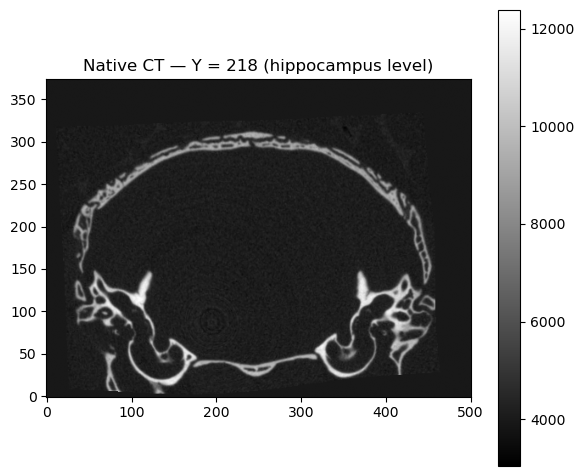

In [14]:
def show_ct_slice(volume, axis, index, title=None, ax=None, cmap='gray', **imkw):
    '''axis: 0/'i'/'x', 1/'j'/'y', 2/'k'/'z' — indexes the native CT array directly.'''
    axis_map = {'x': 0, 'y': 1, 'z': 0, 'i': 0, 'j': 1, 'k': 2}
    ax_idx = axis_map.get(axis, axis) if isinstance(axis, str) else axis
    sl = [slice(None)] * 3
    sl[ax_idx] = index
    img = volume[tuple(sl)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(img.T, origin='lower', cmap=cmap, **imkw)
    ax.set_title(title or f'CT native slice — axis {ax_idx}, index {index}')
    plt.colorbar(im, ax=ax, shrink=0.8)
    return ax

flag = " (SYNTHETIC PLACEHOLDER — not the real skull)" if CT_IS_SYNTHETIC else ""
show_ct_slice(ct_raw, axis='j', index=200,
              title=f'Native CT — Y = 218 (hippocampus level){flag}')
plt.tight_layout(); plt.show()

## 3. CT to acoustic properties (Section 2.1 from Methods, Table 2.1)

Percentile-rescaled intensity, thresholded into a binary skull mask, with literature
mouse-skull constants (Estrada 2016; BBB-hologram paper) assigned inside it -- no
continuous porosity law, since this CT isn't HU-calibrated. CFL is set from the fastest
sound speed in the domain (Section 5), not water alone, or the simulation diverges.

In [15]:
CT_PCTL_LOW, CT_PCTL_HIGH = 1.0, 99.5  # percentiles used to rescale raw CT intensity into [0, 1]


def ct_to_normalized_intensity(ct, pctl_low=CT_PCTL_LOW, pctl_high=CT_PCTL_HIGH):
    # A purely data-driven rescaling of THIS scan's own intensity range -- NOT physical
    # porosity, and NOT Hounsfield Units (this CT isn't HU-calibrated, see §2). 0.0 = low
    # end of the intensity range (water/background), 1.0 = high end (bone).
    ct = ct.astype(np.float32)
    lo, hi = np.percentile(ct, [pctl_low, pctl_high])
    normalized_intensity = (ct - lo) / max(hi - lo, 1e-6)
    return np.clip(normalized_intensity, 0.0, 1.0).astype(np.float32)


normalized_intensity_full = ct_to_normalized_intensity(ct_raw)
print(f"Normalized intensity range: [{normalized_intensity_full.min():.2f}, {normalized_intensity_full.max():.2f}]")

Normalized intensity range: [0.00, 1.00]


In [16]:
# --- Mouse-skull acoustic constants -----------------------------------------
# Density & bulk longitudinal speed: Estrada et al. 2016, Table 2 (avg of 2 ex-vivo adult
# mouse skulls). Absorption: BBB-opening hologram paper's homogeneous mouse-skull value.
BONE_DENSITY = 0.5 * (1969.0 + 1933.0)   # kg/m^3
BONE_SPEED   = 0.5 * (2242.0 + 2425.0)   # m/s
BONE_ALPHA0  = 28.3 / 1.68               # dB/(MHz^gamma . cm), gamma = 1

WATER_ALPHA0 = 0.0   # negligible over these path lengths; raise if you want to model it

# Single global exponent applied across the whole domain (k-Wave's alpha_power must be a
# scalar, only alpha_coeff can vary spatially). Nudged just off 1.0: k-Wave's power-law
# dispersion correction has a tan(pi*y/2) term that is singular exactly at y=1 (Treeby &
# Cox 2010) -- this, not "1 being a bad physical value", is why y=1.01 alone didn't fix
# your blow-up; the timestep bug in §5 was still there.
ALPHA_POWER = 1.01

INTENSITY_THRESHOLD = 0.5   # normalized intensity above this -> "skull" in the binary mask

print(f"BONE_DENSITY = {BONE_DENSITY:.0f} kg/m^3   (Estrada 2016, Table 2)")
print(f"BONE_SPEED   = {BONE_SPEED:.0f} m/s        (Estrada 2016, Table 2)")
print(f"BONE_ALPHA0  = {BONE_ALPHA0:.2f} dB/(MHz.cm)   (BBB hologram paper, gamma=1)")


def build_acoustic_maps(normalized_intensity):
    # Binary mask only: no calibrated HU means no physically-meaningful continuous
    # mixing law (see the §3 markdown above) -- every "skull" voxel gets the same
    # bulk literature constants.
    skull_mask = normalized_intensity > INTENSITY_THRESHOLD
    density = np.where(skull_mask, BONE_DENSITY, RHO_WATER).astype(np.float32)
    speed   = np.where(skull_mask, BONE_SPEED,   C_WATER).astype(np.float32)
    alpha   = np.where(skull_mask, BONE_ALPHA0,  WATER_ALPHA0).astype(np.float32)
    return density, speed, alpha, skull_mask


density_full, speed_full, alpha_full, skull_mask_full = build_acoustic_maps(normalized_intensity_full)
print(f"\nSkull-mask coverage : {skull_mask_full.mean()*100:.1f}% of native CT volume")
print(f"Density range       : [{density_full.min():.0f}, {density_full.max():.0f}] kg/m^3")
print(f"Speed   range       : [{speed_full.min():.0f}, {speed_full.max():.0f}] m/s")
print(f"Alpha   range       : [{alpha_full.min():.2f}, {alpha_full.max():.2f}] dB/(MHz.cm)")

BONE_DENSITY = 1951 kg/m^3   (Estrada 2016, Table 2)
BONE_SPEED   = 2334 m/s        (Estrada 2016, Table 2)
BONE_ALPHA0  = 16.85 dB/(MHz.cm)   (BBB hologram paper, gamma=1)

Skull-mask coverage : 4.0% of native CT volume
Density range       : [997, 1951] kg/m^3
Speed   range       : [1500, 2334] m/s
Alpha   range       : [0.00, 16.85] dB/(MHz.cm)


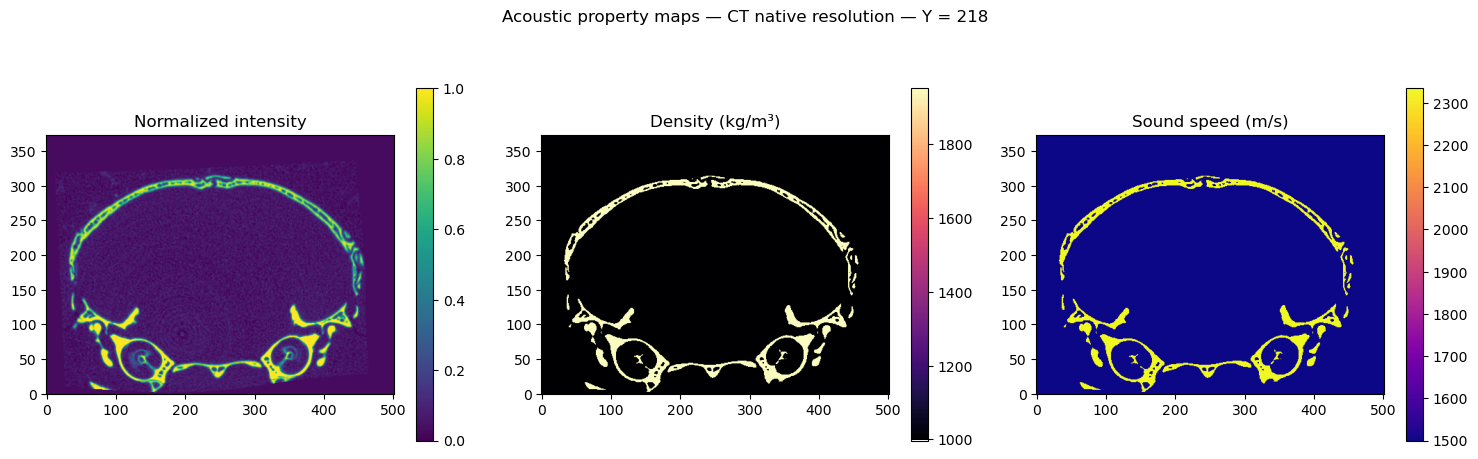

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
y_idx = 218
show_ct_slice(normalized_intensity_full, 'j', y_idx, title='Normalized intensity', ax=axes[0], cmap='viridis', vmin=0, vmax=1)
show_ct_slice(density_full,  'j', y_idx, title='Density (kg/m³)', ax=axes[1], cmap='magma')
show_ct_slice(speed_full,    'j', y_idx, title='Sound speed (m/s)', ax=axes[2], cmap='plasma')
plt.suptitle(f'Acoustic property maps — CT native resolution — Y = {y_idx}'
             + (' [SYNTHETIC]' if CT_IS_SYNTHETIC else ''))
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/ct_acoustic_maps_native_{RUN_TAG}.png', dpi=150)
plt.show()

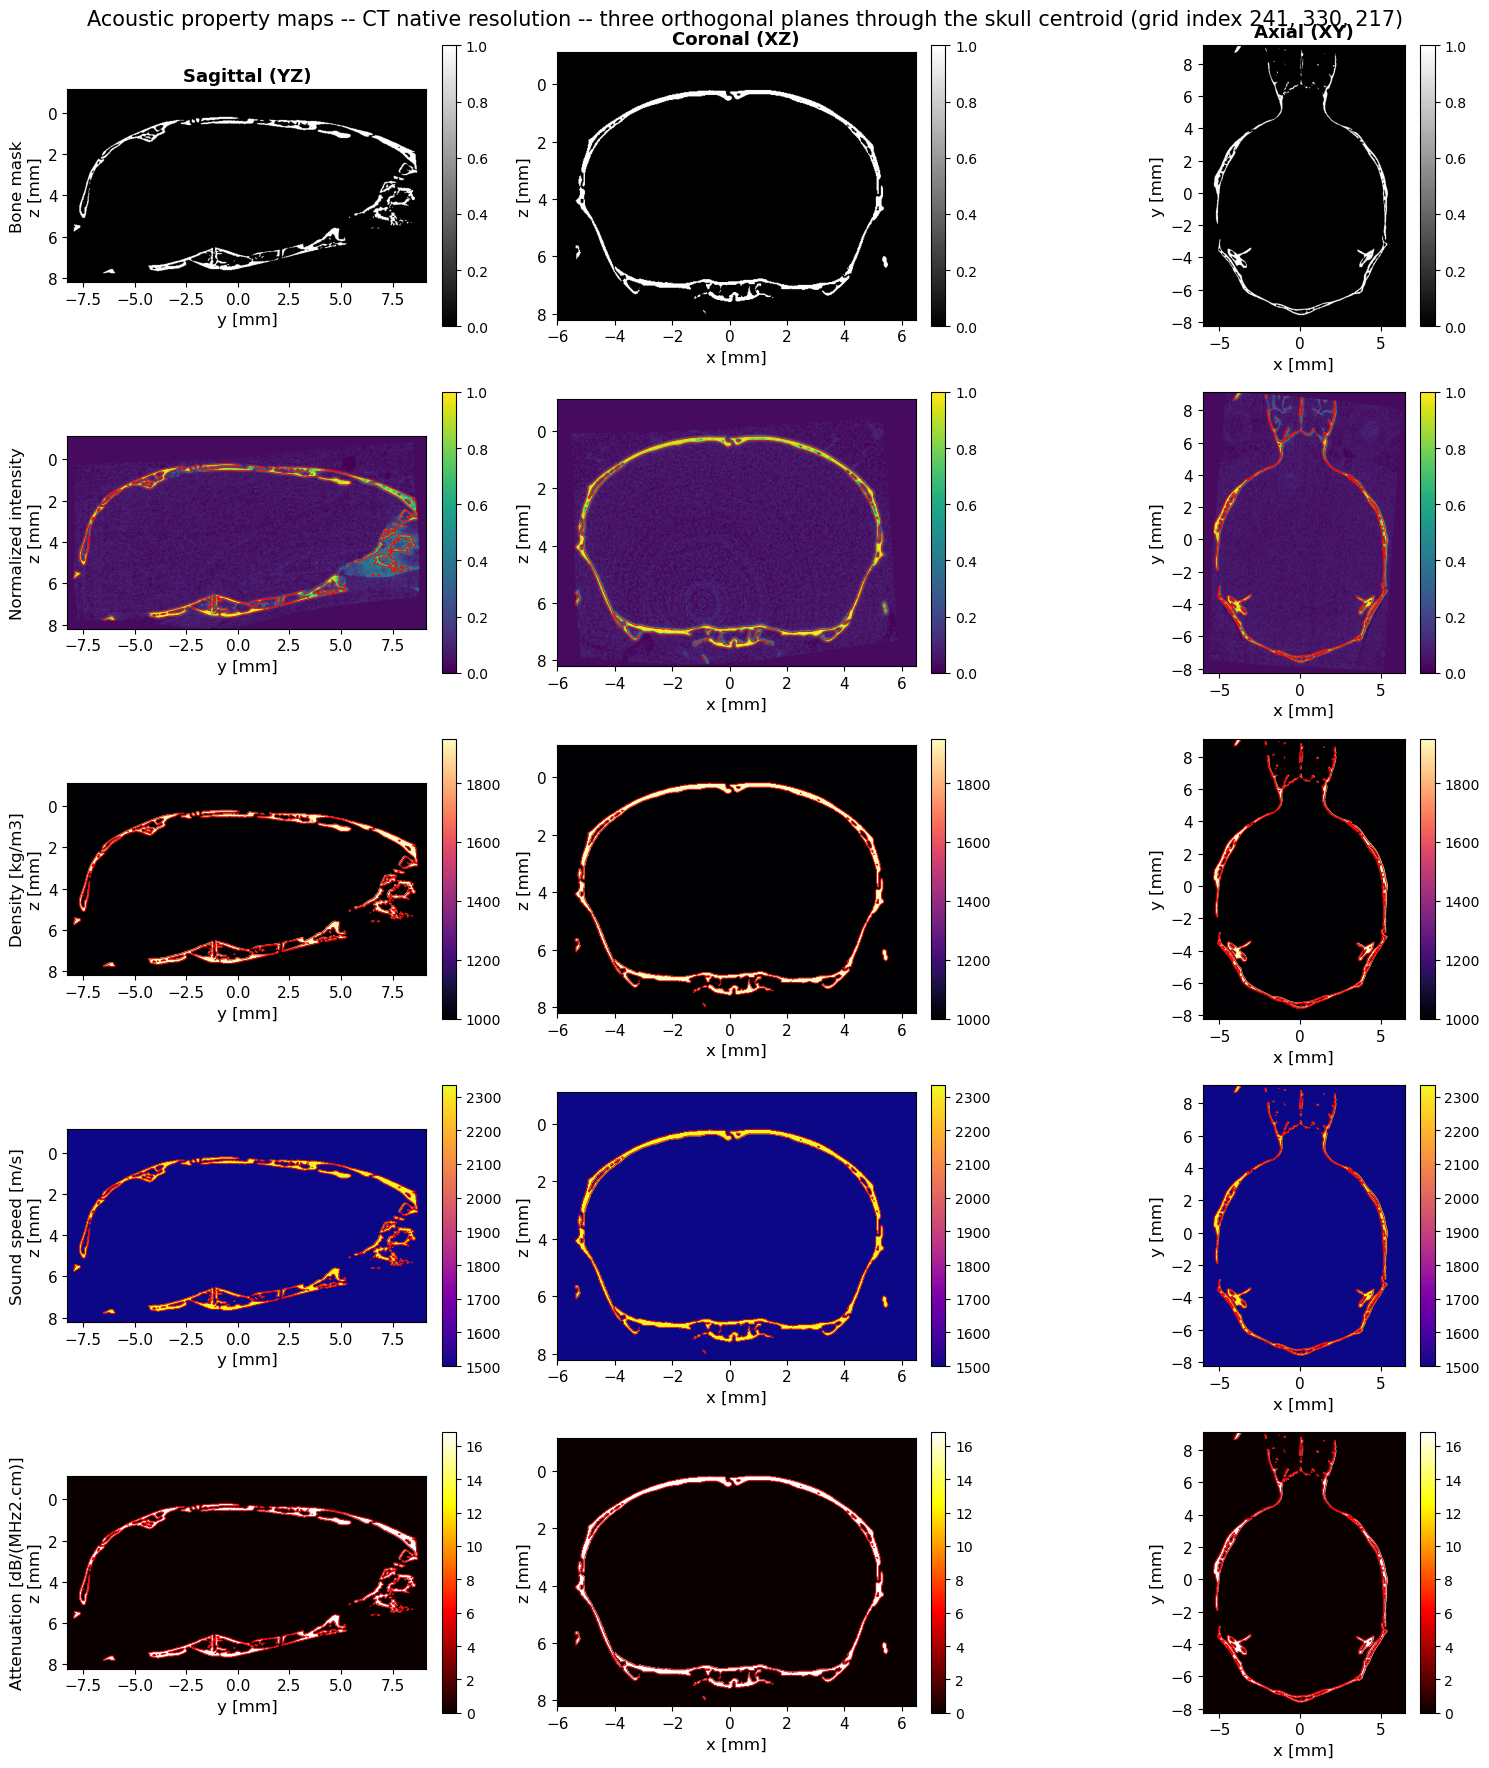

In [18]:
# =========================================================================
# NATIVE-RESOLUTION ACOUSTIC PROPERTY MAPS -- three orthogonal planes
# (normalized_intensity_full / density_full / speed_full / skull_mask_full / alpha_full,
# extending the single-slice 'Acoustic property maps' cell above to all 3 cuts,
# plus a bone-mask row and an attenuation row. Also defines
# _intensity_cuts/_bone_cuts/_h_axes/_v_axes/_ci/_cj/_ck used by the METHODS FIGURE cell
# below.)
# =========================================================================
_intensity_full_flip = normalized_intensity_full[:, :, ::-1]
_den_full_flip = density_full[:, :, ::-1]
_spd_full_flip = speed_full[:, :, ::-1]
_alp_full_flip = alpha_full[:, :, ::-1]
_bone_full_flip = skull_mask_full[:, :, ::-1]

_com_full = np.argwhere(_bone_full_flip).mean(axis=0)
_ci, _cj, _ck = [int(round(c)) for c in _com_full]
_ci = np.clip(_ci, 0, _intensity_full_flip.shape[0] - 1)
_cj = np.clip(_cj, 0, _intensity_full_flip.shape[1] - 1)
_ck = np.clip(_ck, 0, _intensity_full_flip.shape[2] - 1)

# first_bone_z_mm is normally set in the DX_SIM resampling cell below, but this cell runs
# earlier (native-resolution QC, before any resampling) -- compute it here from the same
# native-resolution formula so this cell does not depend on later cells having run first.
if 'first_bone_z_mm' not in dir():
    _bone_z_profile_native = np.any(_intensity_full_flip > INTENSITY_THRESHOLD, axis=(0, 1))
    first_bone_z_mm = int(np.argmax(_bone_z_profile_native)) * ct_voxel_mm[2]

_imm = (np.arange(_intensity_full_flip.shape[0]) - _ci) * ct_voxel_mm[0]
_jmm = (np.arange(_intensity_full_flip.shape[1]) - _cj) * ct_voxel_mm[1]
_kmm = np.arange(_intensity_full_flip.shape[2]) * ct_voxel_mm[2] - first_bone_z_mm   # z=0 at skull surface

def _cut3(vol):
    return [vol[_ci, :, :].T, vol[:, _cj, :].T, vol[:, :, _ck].T]

_bone_cuts = _cut3(_bone_full_flip.astype(float))
_intensity_cuts = _cut3(_intensity_full_flip)
_den_cuts  = _cut3(_den_full_flip)
_spd_cuts  = _cut3(_spd_full_flip)
_alp_cuts  = _cut3(_alp_full_flip)

_h_axes = [_jmm, _imm, _imm]   # sagittal:y, coronal:x, axial:x
_v_axes = [_kmm, _kmm, _jmm]   # sagittal:z, coronal:z, axial:y
_titles = ['Sagittal (YZ)', 'Coronal (XZ)', 'Axial (XY)']
_xlabels = ['y [mm]', 'x [mm]', 'x [mm]']
_ylabels = ['z [mm]', 'z [mm]', 'y [mm]']

fig3, axes3 = plt.subplots(5, 3, figsize=(15, 18))

# vmin/vmax = None lets each panel auto-scale to its own slice's data range,
# same as show_ct_slice() above -- avoids washing out contrast with a
# global (whole-volume) max.
_rows = [
    ('Bone mask',                   _bone_cuts,      'gray',   0,    1),
    ('Normalized intensity',        _intensity_cuts, 'viridis',0,    1),
    ('Density [kg/m3]',             _den_cuts,       'magma',  None, None),
    ('Sound speed [m/s]',           _spd_cuts,       'plasma', None, None),
    ('Attenuation [dB/(MHz2.cm)]',  _alp_cuts,       'hot',    0,    None),
]

for row_idx, (row_label, cuts, cmap, vmin, vmax) in enumerate(_rows):
    for col in range(3):
        ax = axes3[row_idx, col]
        ext = [_h_axes[col][0], _h_axes[col][-1], _v_axes[col][0], _v_axes[col][-1]]
        im = ax.imshow(cuts[col], origin='lower', extent=ext, cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal')
        if row_idx > 0 and _bone_cuts[col].max() > 0:
            ax.contour(_h_axes[col], _v_axes[col], _bone_cuts[col], levels=[0.5],
                       colors='red', linewidths=0.6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row_idx == 0:
            ax.set_title(_titles[col], fontsize=13, fontweight='bold')
        ax.set_xlabel(_xlabels[col], fontsize=12)
        ax.set_ylabel(_ylabels[col], fontsize=12)
        ax.tick_params(labelsize=11)
        if col in (0, 1):
            ax.invert_yaxis()
    axes3[row_idx, 0].set_ylabel(f'{row_label}\n{_ylabels[0]}', fontsize=12)

fig3.suptitle(f'Acoustic property maps -- CT native resolution -- three orthogonal planes '
             f'through the skull centroid (grid index {_ci}, {_cj}, {_ck})', fontsize=15)
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/ct_acoustic_maps_native_3planes.png', dpi=150)
plt.show()


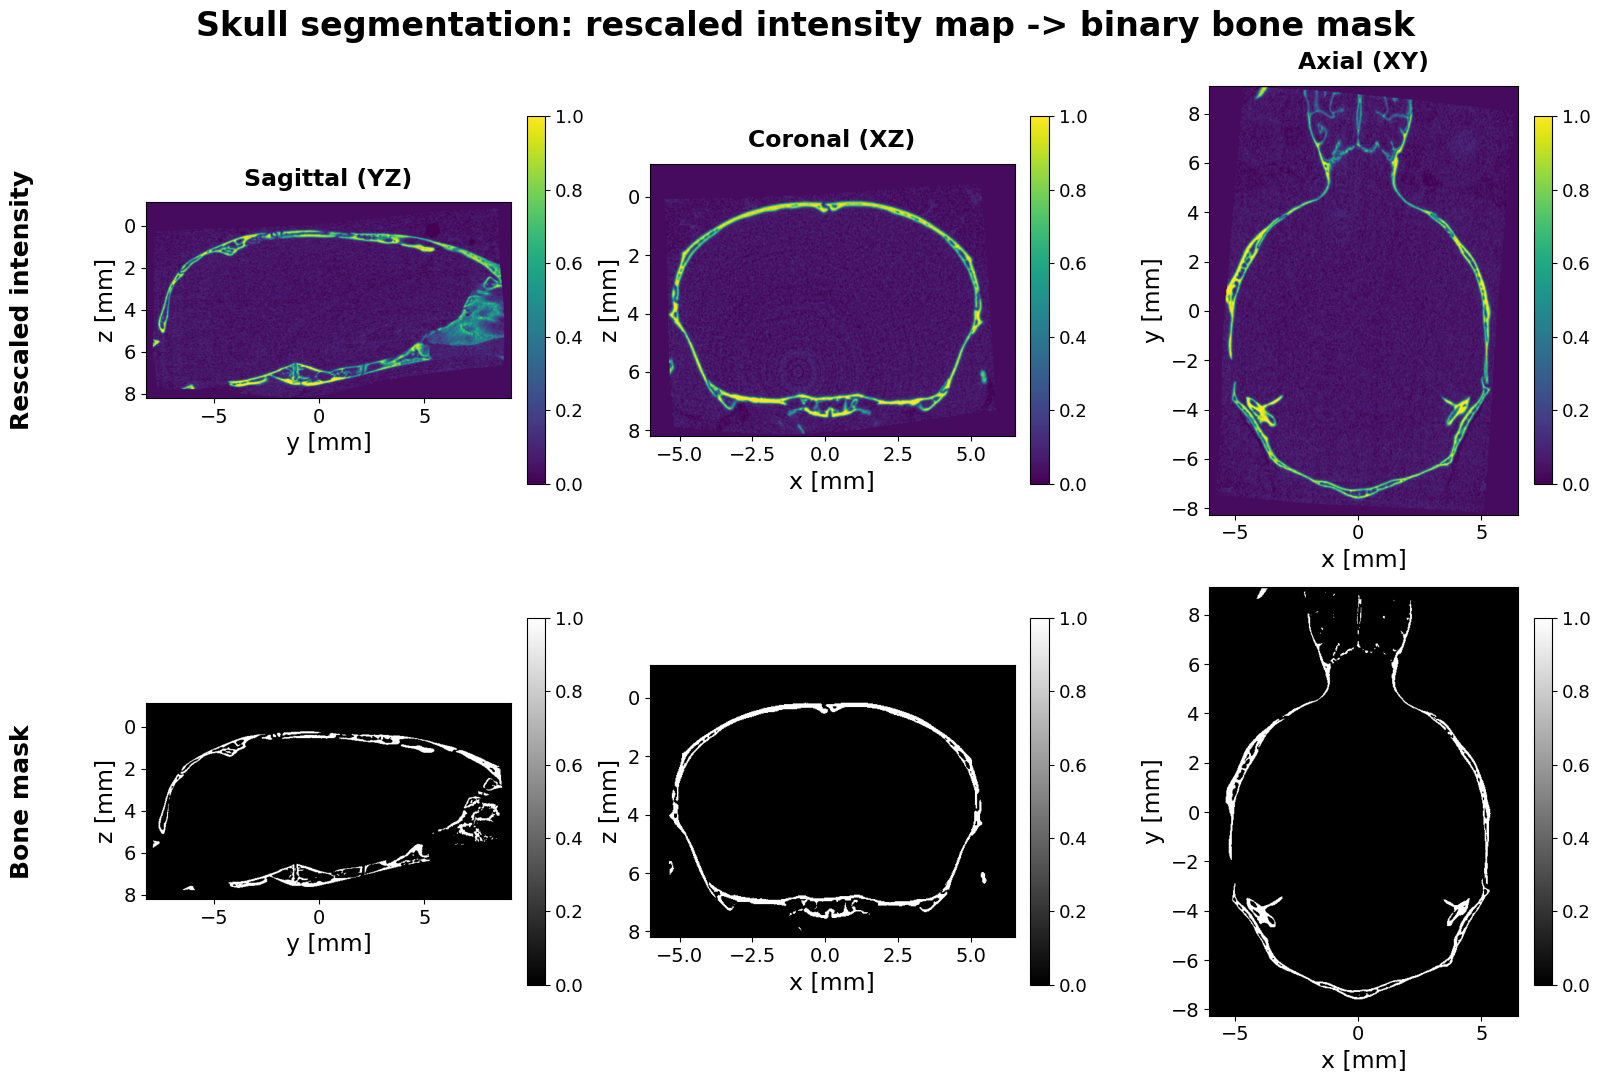

In [19]:
# =========================================================================
# METHODS FIGURE -- skull segmentation (rescaled-intensity map -> binary bone mask)
# Trimmed, publication-sized version of the two cells above: only the two
# panels that actually illustrate the segmentation step described in
# \S skull-properties (rescaled intensity thresholded at INTENSITY_THRESHOLD -> mask).
# Density/speed/attenuation are omitted here since they are just the bone
# mask recoloured with the Table 1 constants, and are already fully specified
# by that table -- reuses _intensity_cuts/_bone_cuts/_h_axes/
# _v_axes/_ci/_cj/_ck computed in the three-orthogonal-planes cell above, so
# run that cell first.
# =========================================================================
_seg_rows = [
    ('Rescaled intensity', _intensity_cuts, 'viridis', 0, 1),
    ('Bone mask',          _bone_cuts,      'gray',    0, 1),
]

fig_seg, axes_seg = plt.subplots(2, 3, figsize=(16, 11))

for row_idx, (row_label, cuts, cmap, vmin, vmax) in enumerate(_seg_rows):
    for col in range(3):
        ax = axes_seg[row_idx, col]
        ext = [_h_axes[col][0], _h_axes[col][-1], _v_axes[col][0], _v_axes[col][-1]]
        im = ax.imshow(cuts[col], origin='lower', extent=ext, cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=13)
        if row_idx == 0:
            ax.set_title(_titles[col], fontsize=17, fontweight='bold', pad=12)
        ax.set_xlabel(_xlabels[col], fontsize=17)
        ax.set_ylabel(_ylabels[col], fontsize=17)
        ax.tick_params(labelsize=14)
        if col in (0, 1):
            ax.invert_yaxis()
    # Row label (bold) as its own annotation, separate from the (unbold) axis unit label --
    # matplotlib can't mix font weights within a single ylabel Text object.
    axes_seg[row_idx, 0].annotate(row_label, xy=(-0.34, 0.5), xycoords='axes fraction',
                                   rotation=90, ha='center', va='center',
                                   fontsize=18, fontweight='bold')

fig_seg.suptitle('Skull segmentation: rescaled intensity map -> binary bone mask', fontsize=24, fontweight='bold')
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/skull_segmentation_intensity_mask.png', dpi=150)
plt.show()

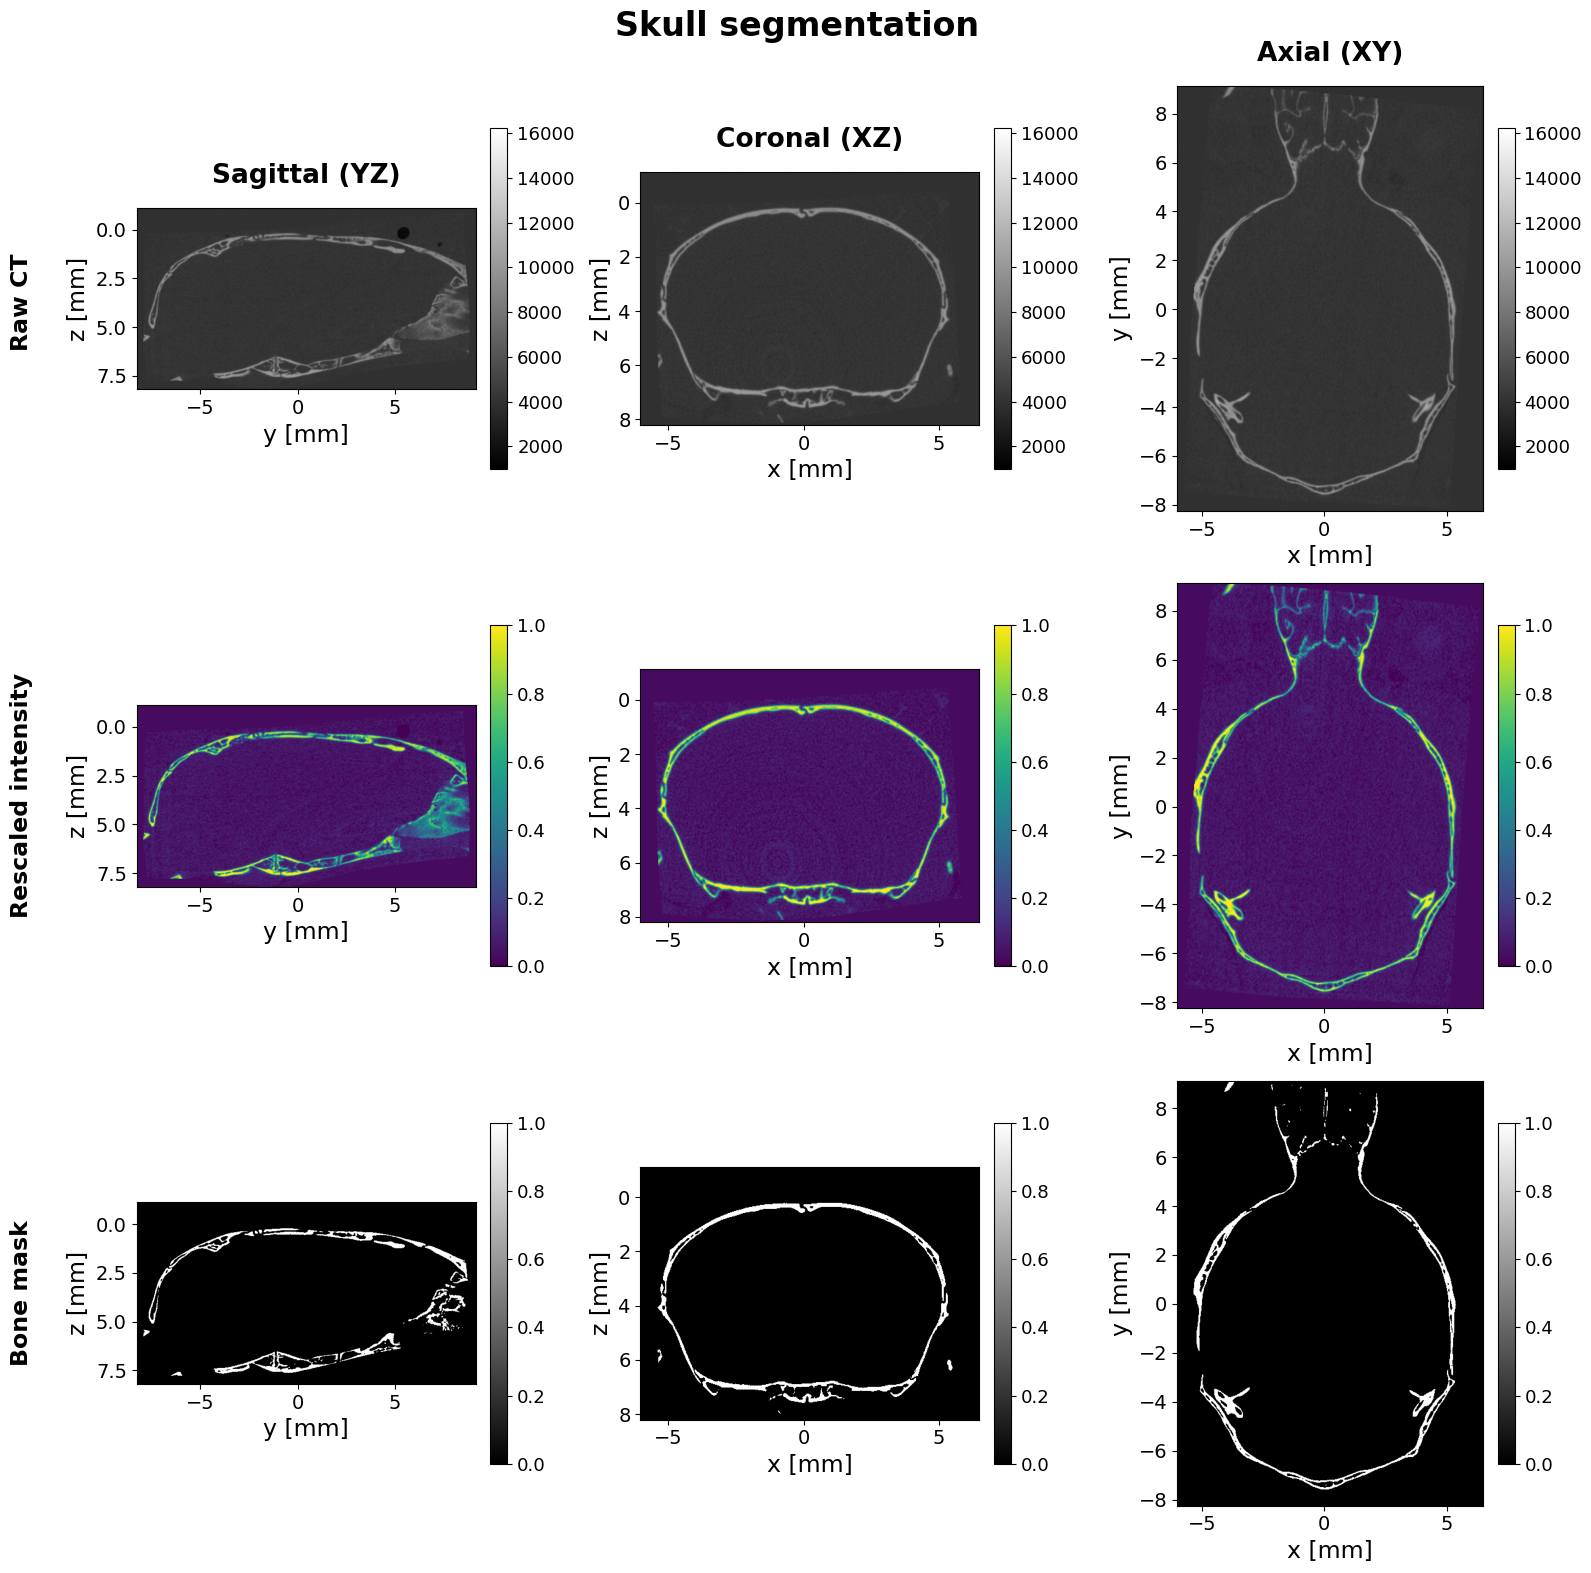

In [20]:
# =========================================================================
# METHODS FIGURE -- skull segmentation, including the raw CT pixel values
# Same three orthogonal planes as the cell above, with an extra top row showing
# the raw (uncalibrated, un-rescaled) CT intensity -- so the mask can be traced
# all the way back to the original uint16 scanner units, before the percentile
# rescaling (Eq. intensity-normalisation) is applied. Reuses _cut3/_ci/_cj/_ck/
# _h_axes/_v_axes/_titles/_xlabels/_ylabels/_intensity_cuts/_bone_cuts computed
# in the three-orthogonal-planes cell above, so run that cell first.
# =========================================================================
_raw_full_flip = ct_raw[:, :, ::-1]
_raw_cuts = _cut3(_raw_full_flip)

# Shared vmin/vmax across all three raw-CT panels (whole-volume min/max), so the
# sagittal/coronal/axial slices are directly comparable on one colour scale --
# unlike the density/speed/attenuation rows elsewhere, which intentionally
# auto-scale per slice.
_raw_vmin, _raw_vmax = float(ct_raw.min()), float(ct_raw.max())

_seg_rows_raw = [
    ('Raw CT ',    _raw_cuts,       'gray',    _raw_vmin, _raw_vmax),
    ('Rescaled intensity', _intensity_cuts, 'viridis', 0,    1),
    ('Bone mask',          _bone_cuts,      'gray',    0,    1),
]

fig_seg_raw, axes_seg_raw = plt.subplots(3, 3, figsize=(16, 16))

for row_idx, (row_label, cuts, cmap, vmin, vmax) in enumerate(_seg_rows_raw):
    for col in range(3):
        ax = axes_seg_raw[row_idx, col]
        ext = [_h_axes[col][0], _h_axes[col][-1], _v_axes[col][0], _v_axes[col][-1]]
        im = ax.imshow(cuts[col], origin='lower', extent=ext, cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=13)
        if row_idx == 0:
            ax.set_title(_titles[col], fontsize=19, fontweight='bold', pad=18)
        ax.set_xlabel(_xlabels[col], fontsize=17)
        ax.set_ylabel(_ylabels[col], fontsize=17)
        ax.tick_params(labelsize=14)
        if col in (0, 1):
            ax.invert_yaxis()
    # Row label (bold) as its own annotation, separate from the (unbold) axis unit label.
    axes_seg_raw[row_idx, 0].annotate(row_label, xy=(-0.34, 0.5), xycoords='axes fraction',
                                       rotation=90, ha='center', va='center',
                                       fontsize=17, fontweight='bold')

fig_seg_raw.suptitle('Skull segmentation', fontsize=24, fontweight='bold')
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/skull_segmentation_raw_intensity_mask.png', dpi=150)
plt.show()

## 4. Resample the skull onto the simulation grid, and place it in the domain
## (Sections 2.1, 2.3 from Methods)

Resamples the intensity map (not the mask) onto `DX_SIM`, then thresholds -- keeps the
mask boundary smooth instead of jagged.

In [21]:
DX_SIM = 75e-6     # m -- simulation grid spacing (fine enough to resolve the thin mouse skull)

# Physical size of the CT sub-volume once resampled to DX_SIM. We resample the continuous
# normalized-intensity map (linear interpolation) rather than an already-binary mask, so the
# mask boundary at DX_SIM isn't jagged/aliased -- thresholding happens *after* resampling.
zoom_factor = ct_voxel_mm * 1e-3 / DX_SIM        # (fi, fj, fk) native-voxels-per-sim-voxel -> scipy zoom factor
normalized_intensity_sim = zoom(normalized_intensity_full, zoom_factor, order=1)
normalized_intensity_sim = normalized_intensity_sim[:, :, ::-1]
print(f"Resampled skull sub-volume: {ct_raw.shape} @ {ct_voxel_mm[0]*1e3:.1f} µm  ->  "
      f"{normalized_intensity_sim.shape} @ {DX_SIM*1e6:.0f} µm")
# NEW: drop any empty margin so the real outer bone surface — not the crop's
# bounding box — is what sits at index 0 (i.e. at the transducer, once pasted).
bone_z_profile = np.any(normalized_intensity_sim > INTENSITY_THRESHOLD, axis=(0, 1))
first_bone_z = int(np.argmax(bone_z_profile))
print(f"Empty margin before real bone starts: {first_bone_z} vox = {first_bone_z*DX_SIM*1e3:.2f} mm")
normalized_intensity_sim = normalized_intensity_sim[:, :, first_bone_z:]

Resampled skull sub-volume: (501, 696, 374) @ 25.0 µm  ->  (167, 232, 125) @ 75 µm
Empty margin before real bone starts: 15 vox = 1.12 mm


In [22]:
# ------------------------------------------------------------------
# Full simulation domain: sized so the skull + focal target both fit comfortably inside.
# ------------------------------------------------------------------
Nx = 184          # 184*75um = 13.8 mm
Ny = 248          # 248*75um = 18.6 mm
Nz = 220          # 220*75um = 16.5 mm


lam_water = C_WATER / F0
print(f"Grid   = {Nx} x {Ny} x {Nz}  = {Nx*Ny*Nz/1e6:.2f} M voxels")
print(f"Domain = {Nx*DX_SIM*1e3:.1f} x {Ny*DX_SIM*1e3:.1f} x {Nz*DX_SIM*1e3:.1f} mm")
print(f"PPW (water) = {lam_water/DX_SIM:.1f}")

# Where the skull sub-volume gets pasted into the domain: an axial standoff
# from the transducer face (z_src = 0, at low-Z) plus a lateral centring offset.
Z_SKULL_START_MM = 0     # mm from transducer face to the outer skull surface
LATERAL_OFFSET_VOX = (0, 0) # (dx, dy) in sim voxels -- shift here once you know the
                             # real hippocampal target's (x, z) from Neuroglancer

def paste_skull_into_domain(normalized_intensity_sub, Nx, Ny, Nz, z_start_mm, dx_sim,
                             lateral_offset_vox=(0, 0)):
    domain = np.zeros((Nx, Ny, Nz), dtype=np.float32)   # normalized_intensity = 0 everywhere = water
    sx, sy, sz = normalized_intensity_sub.shape
    z0 = int(round(z_start_mm * 1e-3 / dx_sim))
    x0 = (Nx - sx) // 2 + lateral_offset_vox[0]
    y0 = (Ny - sy) // 2 + lateral_offset_vox[1]

    # Clip if the (resampled, native-orientation) CT sub-volume is bigger than the domain
    x0c, y0c, z0c = max(x0, 0), max(y0, 0), max(z0, 0)
    x1c, y1c, z1c = min(x0 + sx, Nx), min(y0 + sy, Ny), min(z0 + sz, Nz)
    if x1c <= x0c or y1c <= y0c or z1c <= z0c:
        raise ValueError("Skull sub-volume placement falls entirely outside the domain — "
                          "check Z_SKULL_START_MM / Nx,Ny,Nz / DX_SIM.")
    sub_x0, sub_y0, sub_z0 = x0c - x0, y0c - y0, z0c - z0
    domain[x0c:x1c, y0c:y1c, z0c:z1c] = normalized_intensity_sub[
        sub_x0:sub_x0 + (x1c - x0c), sub_y0:sub_y0 + (y1c - y0c), sub_z0:sub_z0 + (z1c - z0c)]
    placement = dict(x0=x0c, x1=x1c, y0=y0c, y1=y1c, z0=z0c, z1=z1c)
    return domain, placement

normalized_intensity_domain, skull_placement = paste_skull_into_domain(
    normalized_intensity_sim, Nx, Ny, Nz, Z_SKULL_START_MM, DX_SIM, LATERAL_OFFSET_VOX)
density_domain, speed_domain, alpha_domain, skull_mask_domain = build_acoustic_maps(normalized_intensity_domain)
print("Skull placed at voxel range:", skull_placement)
print(f"Domain speed range [{speed_domain.min():.0f}, {speed_domain.max():.0f}] m/s, "
      f"alpha range [{alpha_domain.min():.2f}, {alpha_domain.max():.2f}] dB/(MHz.cm)")

Grid   = 184 x 248 x 220  = 10.04 M voxels
Domain = 13.8 x 18.6 x 16.5 mm
PPW (water) = 32.0
Skull placed at voxel range: {'x0': 8, 'x1': 175, 'y0': 8, 'y1': 240, 'z0': 0, 'z1': 110}
Domain speed range [1500, 2334] m/s, alpha range [0.00, 16.85] dB/(MHz.cm)


## 5. k-Wave grid, medium, source and sensor
## (Sections 2.3, 2.4.1, 2.4.2 from Methods)

In [23]:
kgrid = kWaveGrid([Nx, Ny, Nz], [DX_SIM, DX_SIM, DX_SIM])

medium_skull = kWaveMedium(sound_speed=speed_domain, density=density_domain,
                            alpha_coeff=alpha_domain, alpha_power=ALPHA_POWER)
medium_free  = kWaveMedium(sound_speed=C_WATER, density=RHO_WATER)   # in-notebook free-field control

# --- CFL / timestep: use the FASTEST sound speed anywhere in either medium ---------------
# kgrid.makeTime(C_WATER, ...) alone would size dt for water only, but the skull is faster
# than water -- under-resolving that violates the CFL condition and the field diverges.
# Always derive dt from max(sound_speed) across every medium run on this kgrid.
C_MAX_DOMAIN = float(max(C_WATER, speed_domain.max()))
T_END = 40e-6
kgrid.makeTime(C_MAX_DOMAIN, cfl=0.1, t_end=T_END)

# --- Free-field grid: homogeneous water only -> bigger dt, fewer time steps ---
kgrid_free = kWaveGrid([Nx, Ny, Nz], [DX_SIM, DX_SIM, DX_SIM])
kgrid_free.makeTime(C_WATER, cfl=0.3, t_end=T_END)

print(f"[Skull] C_MAX_DOMAIN = {C_MAX_DOMAIN:.0f} m/s   dt = {kgrid.dt*1e9:.2f} ns   Nt = {kgrid.Nt}")
print(f"[Free ] C_MAX_DOMAIN = {C_WATER:.0f} m/s   dt = {kgrid_free.dt*1e9:.2f} ns   Nt = {kgrid_free.Nt}")
print(f"Speedup on time-stepping alone: {kgrid.Nt/kgrid_free.Nt:.2f}x fewer steps for free-field")

print(f"CFL check [skull]: c_max*dt/dx = {C_MAX_DOMAIN*kgrid.dt/DX_SIM:.3f}  (should be <= ~0.3)")
print(f"CFL check [free] : c_max*dt/dx = {C_WATER*kgrid_free.dt/DX_SIM:.3f}  (should be <= ~0.3)")
print(f"PPP check [skull]: {1/(F0*kgrid.dt):.1f} points/period at F0")
print(f"PPP check [free] : {1/(F0*kgrid_free.dt):.1f} points/period at F0")

[Skull] C_MAX_DOMAIN = 2334 m/s   dt = 3.21 ns   Nt = 12446
[Free ] C_MAX_DOMAIN = 1500 m/s   dt = 15.00 ns   Nt = 2667
Speedup on time-stepping alone: 4.67x fewer steps for free-field
CFL check [skull]: c_max*dt/dx = 0.100  (should be <= ~0.3)
CFL check [free] : c_max*dt/dx = 0.300  (should be <= ~0.3)
PPP check [skull]: 497.8 points/period at F0
PPP check [free] : 106.7 points/period at F0


In [24]:
z_src = 0
xc, yc = Nx // 2, Ny // 2
x_mm3 = (np.arange(Nx) - xc)    * DX_SIM * 1e3
y_mm3 = (np.arange(Ny) - yc)    * DX_SIM * 1e3
z_mm3 = (np.arange(Nz) - z_src) * DX_SIM * 1e3

### 5.1 Transducer source signal (Section 2.6.1 from Methods)

Tone burst, then a Morlet wavelet that overwrites the same variables -- only one should
run before Section 8; whichever runs last is what actually drives the simulation.

In [25]:
# Ring source (Section 2.4.1 from Methods), on the Nx x Ny x Nz grid above


TARGET_Y_IDX = yc   # true beam-symmetry axis (Y = 0 mm) -- appropriate for on-axis validation
x = (np.arange(Nx) - xc) * DX_SIM
y = (np.arange(Ny) - TARGET_Y_IDX) * DX_SIM
X, Y = np.meshgrid(x, y, indexing='ij')
R = np.sqrt(X**2 + Y**2)
ring2d = (R >= ID/2) & (R <= OD/2)
src_mask = np.zeros((Nx, Ny, Nz), dtype=bool)
src_mask[:, :, z_src] = ring2d
n_src = int(ring2d.sum())

sig_skull = np.atleast_2d(tone_burst(1/kgrid.dt,      F0, N_CYCLES)) * P0
sig_free  = np.atleast_2d(tone_burst(1/kgrid_free.dt, F0, N_CYCLES)) * P0
input_signal_skull = np.tile(sig_skull, (n_src, 1)).astype(np.float32)
input_signal_free  = np.tile(sig_free,  (n_src, 1)).astype(np.float32)

source_skull = kSource()
source_skull.p_mask = src_mask
source_skull.p      = input_signal_skull

source_free = kSource()
source_free.p_mask = src_mask
source_free.p      = input_signal_free

sensor = kSensor()
sensor.mask   = np.ones((Nx, Ny, Nz), dtype=bool)
sensor.record = ['p_max', 'p_min']

sim_opts_common = dict(pml_inside=False, data_cast='single', save_to_disk=True)
exec_opts = SimulationExecutionOptions(is_gpu_simulation=False, delete_data=False, verbose_level=1)



In [26]:
# =========================================================================
# Morlet-wavelet source -- same construction as the tone-burst cell above, with
# a Morlet wavelet instead of tone_burst(). Writes to the SAME variable names
# (sig_skull/sig_free/input_signal_skull/input_signal_free/source_skull/
# source_free) as that cell -- run ONE of the two source cells, not both, and
# every cell downstream picks up whichever was run without any changes needed.
# =========================================================================
def morlet_wavelet(sample_freq, signal_freq, num_cycles):
    '''Real Morlet wavelet: cos(2*pi*f0*t) under a Gaussian envelope, with the
    envelope duration matched to an equivalent num_cycles-cycle tone burst
    (num_cycles / signal_freq), so it's directly comparable to tone_burst().'''
    dt = 1 / sample_freq
    duration = num_cycles / signal_freq
    t = np.arange(-duration / 2, duration / 2, dt)
    sigma = duration / 6   # +/-3 sigma spans the full duration (matches k-Wave's own Gaussian window)
    envelope = np.exp(-t**2 / (2 * sigma**2))
    return envelope * np.cos(2 * np.pi * signal_freq * t)

sig_skull = np.atleast_2d(morlet_wavelet(1/kgrid.dt,      F0, N_CYCLES)) * P0
sig_free  = np.atleast_2d(morlet_wavelet(1/kgrid_free.dt, F0, N_CYCLES)) * P0
input_signal_skull = np.tile(sig_skull, (n_src, 1)).astype(np.float32)
input_signal_free  = np.tile(sig_free,  (n_src, 1)).astype(np.float32)

source_skull = kSource()
source_skull.p_mask = src_mask
source_skull.p      = input_signal_skull

source_free = kSource()
source_free.p_mask = src_mask
source_free.p      = input_signal_free

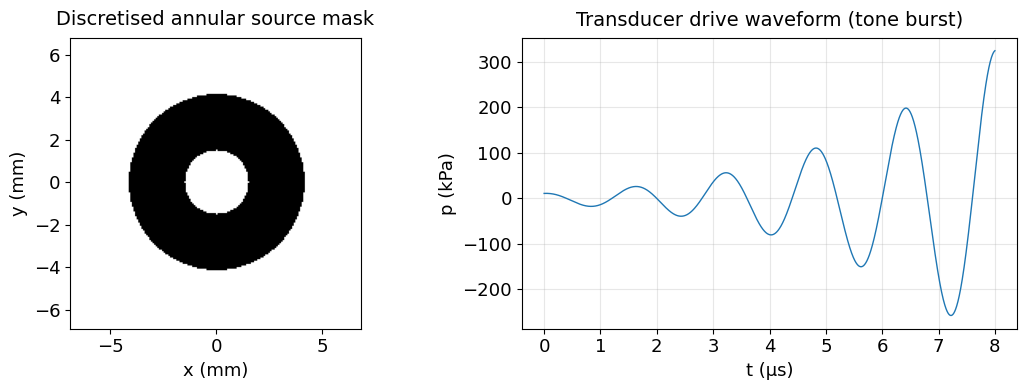

In [27]:
# Quick visual sanity check of the source mask + a few cycles of the signal
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(src_mask[:, :, z_src].T,
             extent=[x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3],
             origin='lower', cmap='Greys')
ax[0].set_xlabel('x (mm)', fontsize=13); ax[0].set_ylabel('y (mm)', fontsize=13)
ax[0].tick_params(axis='both', labelsize=13)
ax[0].set_title('Discretised annular source mask', fontsize=14,  pad=9)
ax[0].set_aspect('equal')
# x and y spans differ slightly (Nx != Ny), so force identical axis limits on both --
# use the tighter (smaller) of the two extents so the plot stays cropped to the ring,
# not padded out to whichever axis happens to be larger.
_ring_lo = max(x[0], y[0]) * 1e3
_ring_hi = min(x[-1], y[-1]) * 1e3
ax[0].set_xlim(_ring_lo, _ring_hi)
ax[0].set_ylim(_ring_lo, _ring_hi)

t = np.arange(input_signal_skull.shape[1]) * kgrid.dt * 1e6
# Preview window sized by physical time (a few periods of F0), not a fixed sample count --
# a fixed count of samples covers wildly different durations depending on kgrid.dt (here
# ~3.2 ns for the bone-inclusive transcranial grid vs ~15 ns for free-field water only, see
# the CFL/C_MAX_DOMAIN cell above), so a fixed-count window can silently show less than one
# cycle instead of the intended few cycles of the tone burst.
N_PREVIEW_CYCLES = 5
n_preview = min(int(np.ceil(N_PREVIEW_CYCLES / F0 / kgrid.dt)), len(t))
ax[1].plot(t[:n_preview], input_signal_skull[0, :n_preview]/1e3, lw=1)
ax[1].set_xlabel('t (µs)', fontsize=13); ax[1].set_ylabel('p (kPa)', fontsize=13)
ax[1].tick_params(axis='both', labelsize=13)
ax[1].set_title('Transducer drive waveform (tone burst)', fontsize=14, pad=9)
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/source_check.png', dpi=150); plt.show()

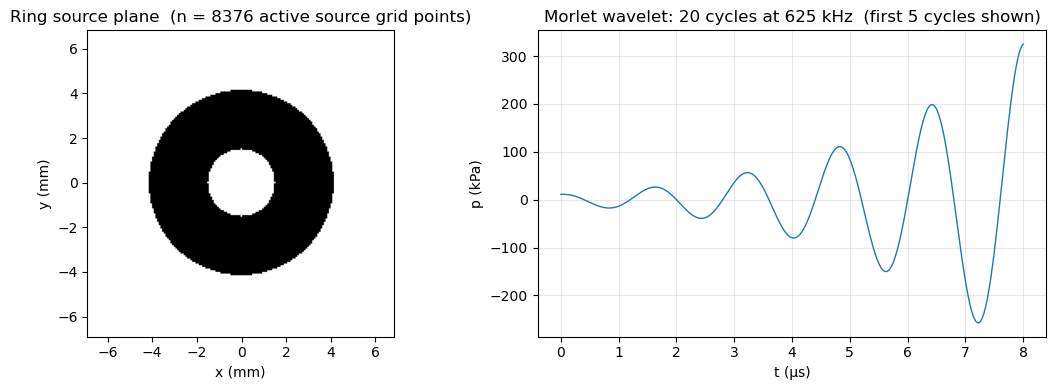

In [28]:
# Quick visual sanity check of the source mask + a few cycles of the Morlet-wavelet signal
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(src_mask[:, :, z_src].T,
             extent=[x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3],
             origin='lower', cmap='Greys')
ax[0].set_xlabel('x (mm)'); ax[0].set_ylabel('y (mm)')
ax[0].set_title(f'Ring source plane  (n = {n_src} active source grid points)')
ax[0].set_aspect('equal')
# x and y spans differ slightly (Nx != Ny), so force identical axis limits on both --
# use the tighter (smaller) of the two extents so the plot stays cropped to the ring,
# not padded out to whichever axis happens to be larger.
_ring_lo = max(x[0], y[0]) * 1e3
_ring_hi = min(x[-1], y[-1]) * 1e3
ax[0].set_xlim(_ring_lo, _ring_hi)
ax[0].set_ylim(_ring_lo, _ring_hi)

t_morlet = np.arange(input_signal_skull.shape[1]) * kgrid.dt * 1e6
# Same physical-time preview window logic as the tone-burst check above -- a fixed sample
# count would cover a different duration depending on kgrid.dt, so size it by cycles of F0.
N_PREVIEW_CYCLES = 5
n_preview_morlet = min(int(np.ceil(N_PREVIEW_CYCLES / F0 / kgrid.dt)), len(t_morlet))
ax[1].plot(t_morlet[:n_preview_morlet], input_signal_skull[0, :n_preview_morlet]/1e3, lw=1)
ax[1].set_xlabel('t (µs)'); ax[1].set_ylabel('p (kPa)')
ax[1].set_title(f'Morlet wavelet: {N_CYCLES} cycles at {F0/1e3:.0f} kHz  (first {N_PREVIEW_CYCLES} cycles shown)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/source_check_morlet.png', dpi=150); plt.show()

## 6. Sanity checks -- skull placement & source geometry

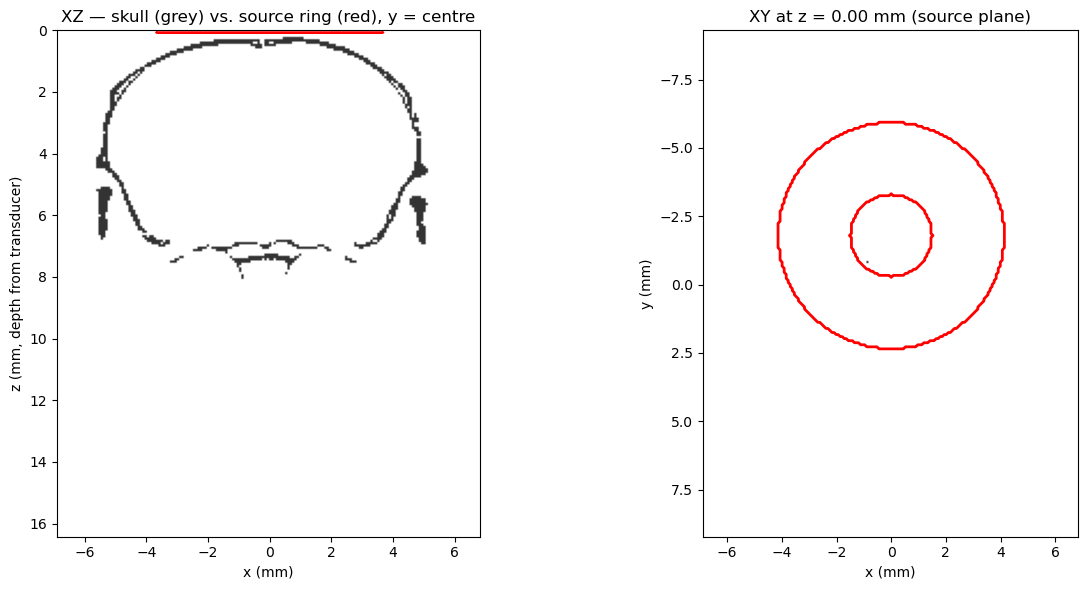

In [29]:
# =========================================================================
# SANITY CHECK: CT skull vs. ring source -- 2D orthogonal slices
# =========================================================================
x_mm_chk = (np.arange(Nx) - xc)    * DX_SIM * 1e3
y_mm_chk = (np.arange(Ny) - yc)    * DX_SIM * 1e3
z_mm_chk = (np.arange(Nz) - z_src) * DX_SIM * 1e3


fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- XZ slice through the beam axis (y = centre) -- shows standoff + skull depth ---
ax = axes[0]
skull_xz = skull_mask_domain[:, yc, :].T.astype(float)
src_xz   = src_mask[:, yc, :].T.astype(float)
extent_xz = [x_mm_chk[0], x_mm_chk[-1], z_mm_chk[-1], z_mm_chk[0]]
ax.imshow(skull_xz, origin='upper', extent=extent_xz, cmap='Greys', vmin=0, vmax=1,
          aspect='equal', alpha=0.8)
ax.contour(src_xz, levels=[0.5], colors='red', linewidths=2, extent=extent_xz, origin='upper')
ax.set_xlabel('x (mm)'); ax.set_ylabel('z (mm, depth from transducer)')
ax.set_title('XZ — skull (grey) vs. source ring (red), y = centre')

# --- XY slice at the source plane (z = z_src) -- confirms no skull/source overlap ---
ax = axes[1]
skull_xy = skull_mask_domain[:, :, z_src].T.astype(float)
src_xy   = src_mask[:, :, z_src].T.astype(float)
extent_xy = [x_mm_chk[0], x_mm_chk[-1], y_mm_chk[-1], y_mm_chk[0]]
ax.imshow(skull_xy, origin='upper', extent=extent_xy, cmap='Greys', vmin=0, vmax=1,
          aspect='equal', alpha=0.8)
ax.contour(src_xy, levels=[0.5], colors='red', linewidths=2, extent=extent_xy, origin='upper')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title(f'XY at z = {z_mm_chk[z_src]:.2f} mm (source plane)')

plt.tight_layout(); plt.show()

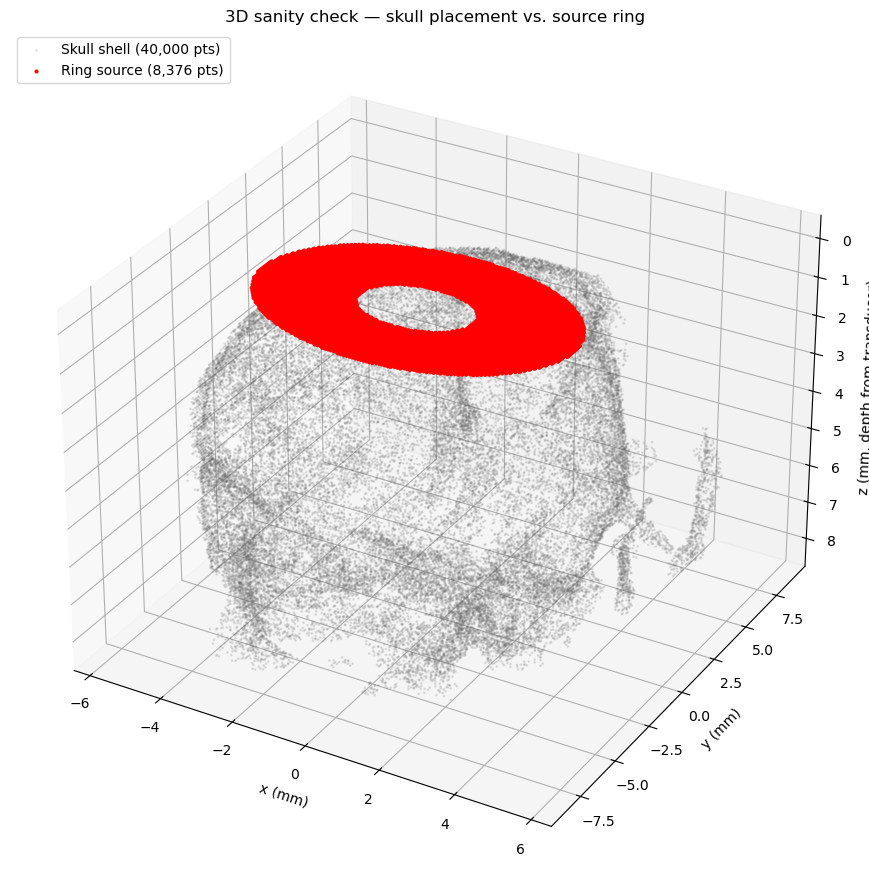

In [30]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the 3d projection
from scipy.ndimage import binary_erosion



# Skull shell only (surface voxels) -- the solid interior would be ~10^5-10^6 points, unusable in matplotlib
skull_shell = skull_mask_domain & ~binary_erosion(skull_mask_domain, iterations=1)
skull_idx = np.argwhere(skull_shell)

MAX_SKULL_POINTS = 40000
if len(skull_idx) > MAX_SKULL_POINTS:
    rng = np.random.default_rng(0)
    skull_idx = skull_idx[rng.choice(len(skull_idx), MAX_SKULL_POINTS, replace=False)]

src_idx = np.argwhere(src_mask)   # ring is one thin plane -- already small

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_mm3[skull_idx[:, 0]], y_mm3[skull_idx[:, 1]], z_mm3[skull_idx[:, 2]],
           s=1, c='dimgray', alpha=0.15, label=f'Skull shell ({len(skull_idx):,} pts)')
ax.scatter(x_mm3[src_idx[:, 0]], y_mm3[src_idx[:, 1]], z_mm3[src_idx[:, 2]],
           s=4, c='red', alpha=0.9, label=f'Ring source ({len(src_idx):,} pts)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)'); ax.set_zlabel('z (mm, depth from transducer)')
ax.set_title('3D sanity check — skull placement vs. source ring')
ax.legend(loc='upper left')
ax.invert_zaxis()
plt.tight_layout(); plt.show()

In [31]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=x_mm3[skull_idx[:, 0]], y=y_mm3[skull_idx[:, 1]], z=z_mm3[skull_idx[:, 2]],
    mode='markers',
    marker=dict(size=1.5, color='dimgray', opacity=0.15),
    name=f'Skull shell ({len(skull_idx):,} pts)'
))
fig.add_trace(go.Scatter3d(
    x=x_mm3[src_idx[:, 0]], y=y_mm3[src_idx[:, 1]], z=z_mm3[src_idx[:, 2]],
    mode='markers',
    marker=dict(size=2.5, color='red', opacity=0.9),
    name=f'Ring source ({len(src_idx):,} pts)'
))
fig.update_layout(
    title='3D sanity check — skull placement vs. source ring (drag to rotate, scroll to zoom)',
    scene=dict(
        xaxis_title='x (mm)', yaxis_title='y (mm)', zaxis_title='z (mm, depth from transducer)',
        zaxis=dict(autorange='reversed'),   # depth increases downward, matching invert_zaxis() before
        aspectmode='data',                  # true geometric proportions, not auto-stretched
    ),
    legend=dict(itemsizing='constant'),
    width=850, height=850,
)
fig.show()

## 7. Fast reload -- load existing simulation outputs from disk

Reads grid dimensions from each file's own metadata, so this works after a kernel
restart without re-running Sections 2-6.

In [38]:
import os, h5py

RESULTS_DIR = r"C:\Users\lucia\OneDrive - Imperial College London\msc project\Kwave simulations\results_transcranial4"
free_path  = os.path.join(RESULTS_DIR, "out_freefield_623kHz_1p00MPa.h5")
skull_path = os.path.join(RESULTS_DIR, "out_transcranial_623kHz_1p00MPa.h5")

def load_p_min(path):
    with h5py.File(path, 'r') as f:
        # Nx/Ny/Nz in the file include PML padding on both sides of each axis;
        # p_min is only recorded on the interior sensor grid, so subtract it off.
        Nx, Ny, Nz = int(f['Nx'][0,0,0]), int(f['Ny'][0,0,0]), int(f['Nz'][0,0,0])
        px, py, pz = int(f['pml_x_size'][0,0,0]), int(f['pml_y_size'][0,0,0]), int(f['pml_z_size'][0,0,0])
        Nx, Ny, Nz = Nx - 2*px, Ny - 2*py, Nz - 2*pz
        p_min = f['p_min'][:].squeeze().reshape((Nx, Ny, Nz), order='F')
    return p_min

p_min_free  = load_p_min(free_path)
p_min_skull = load_p_min(skull_path)

print(f"p_min_free  shape={p_min_free.shape}  min={p_min_free.min()/1e6:.3f} MPa")
print(f"p_min_skull shape={p_min_skull.shape}  min={p_min_skull.min()/1e6:.3f} MPa")

def load_p_max(path):
    with h5py.File(path, 'r') as f:
        # Nx/Ny/Nz in the file include PML padding on both sides of each axis;
        # p_max is only recorded on the interior sensor grid, so subtract it off.
        Nx, Ny, Nz = int(f['Nx'][0,0,0]), int(f['Ny'][0,0,0]), int(f['Nz'][0,0,0])
        px, py, pz = int(f['pml_x_size'][0,0,0]), int(f['pml_y_size'][0,0,0]), int(f['pml_z_size'][0,0,0])
        Nx, Ny, Nz = Nx - 2*px, Ny - 2*py, Nz - 2*pz
        p_max = f['p_max'][:].squeeze().reshape((Nx, Ny, Nz), order='F')
    return p_max

p_max_free  = load_p_max(free_path)
p_max_skull = load_p_max(skull_path)

pnp_field_free = -p_min_free
pnp_field_skull = -p_min_skull

p_min_free  shape=(184, 248, 220)  min=-1.972 MPa
p_min_skull shape=(184, 248, 220)  min=-2.487 MPa


## 8. Run both simulations -- free-field control & transcranial
## (Sections 2.4.2, 2.5 from Methods)

Same source, same grid -- only the medium differs, so the two runs are directly comparable.

In [19]:
sim_opts_free = SimulationOptions(
    input_filename  = os.path.join(OUTPUT_DIR, f'in_freefield_{RUN_TAG}.h5'),
    output_filename = os.path.join(OUTPUT_DIR, f'out_freefield_{RUN_TAG}.h5'),
    **sim_opts_common)

out_free_filename = os.path.join(OUTPUT_DIR, f'out_freefield_{RUN_TAG}.h5')
if os.path.exists(out_free_filename):
    # already simulated in a previous run -- load the saved output instead of re-running
    import h5py
    with h5py.File(out_free_filename, 'r') as f:
        out_free = {k: f[k][:].squeeze() for k in f.keys()}
    print(f"Loaded existing free-field output from {out_free_filename}")
else:
    out_free = kspaceFirstOrder3DC(kgrid=kgrid_free, medium=medium_free, source=source_free, sensor=sensor,
                                    simulation_options=sim_opts_free, execution_options=exec_opts)
p_max_free = out_free['p_max'].reshape((Nx, Ny, Nz), order='F')

c:\Users\lucia\anaconda3\Lib\site-packages\kwave\options\simulation_execution_options.py:111: UserWarning: Custom binary name set. Ignoring `is_gpu_simulation` state.
  warnings.warn("Custom binary name set. Ignoring `is_gpu_simulation` state.")


+---------------------------------------------------------------+
|                   kspaceFirstOrder-OMP v1.3                   |
+---------------------------------------------------------------+
| Reading simulation configuration:                        Done |
| Number of CPU threads:                                     16 |
| Processor name:                Intel(R) Core(TM) Ultra 7 255H |
+---------------------------------------------------------------+
|                      Simulation details                       |
+---------------------------------------------------------------+
| Domain dimensions:                            204 x 268 x 240 |
| Medium type:                                               3D |
| Simulation time steps:                                   2667 |
+---------------------------------------------------------------+
| Input file:  c:\Users\lucia\OneDrive - Imperial College       |
|              London\msc project\Kwave simulations\results_    |
|         

In [20]:
p_min_free = out_free['p_min'].reshape((Nx, Ny, Nz), order='F')
pnp_field_free = -p_min_free   # positive-magnitude PNP field


In [37]:
sim_opts_skull = SimulationOptions(
    input_filename  = os.path.join(OUTPUT_DIR, f'in_transcranial_{RUN_TAG}.h5'),
    output_filename = os.path.join(OUTPUT_DIR, f'out_transcranial_{RUN_TAG}.h5'),
    **sim_opts_common)

out_skull = kspaceFirstOrder3DC(kgrid=kgrid, medium=medium_skull, source=source_skull, sensor=sensor,
                                 simulation_options=sim_opts_skull, execution_options=exec_opts)

p_max_skull = out_skull['p_max'].reshape((Nx, Ny, Nz), order='F')


c:\Users\lucia\anaconda3\Lib\site-packages\kwave\options\simulation_execution_options.py:111: UserWarning:

Custom binary name set. Ignoring `is_gpu_simulation` state.



+---------------------------------------------------------------+
|                   kspaceFirstOrder-OMP v1.3                   |
+---------------------------------------------------------------+
| Reading simulation configuration:                        Done |
| Number of CPU threads:                                     16 |
| Processor name:                Intel(R) Core(TM) Ultra 7 255H |
+---------------------------------------------------------------+
|                      Simulation details                       |
+---------------------------------------------------------------+
| Domain dimensions:                            204 x 268 x 240 |
| Medium type:                                               3D |
| Simulation time steps:                                  12446 |
+---------------------------------------------------------------+
| Input file:  c:\Users\lucia\OneDrive - Imperial College       |
|              London\msc project\Kwave simulations\results_    |
|         

In [48]:
p_min_skull = out_skull['p_min'].reshape((Nx, Ny, Nz), order='F')
pnp_field_skull = -p_min_skull   # positive-magnitude PNP field


## 9. Focal metrics: peak pressure and peak negative pressure
## (Section 2.5 from Methods / Section 3.1 from Results)

In [39]:
x_mm = (np.arange(Nx) - xc)           * DX_SIM * 1e3
y_mm = (np.arange(Ny) - TARGET_Y_IDX) * DX_SIM * 1e3
z_mm = (np.arange(Nz) - z_src)        * DX_SIM * 1e3

def fwhm(prof, axis_mm):
    pk = prof.max()
    if pk <= 0: return np.nan, np.nan, np.nan
    above = np.where(prof >= pk/2)[0]
    if len(above) < 2: return np.nan, np.nan, np.nan
    return axis_mm[above[-1]] - axis_mm[above[0]], axis_mm[above[0]], axis_mm[above[-1]]

def focal_metrics(p_max, label):
    axial = p_max[xc, TARGET_Y_IDX, :]
    fz = int(np.argmax(axial))
    lat = p_max[:, TARGET_Y_IDX, fz]
    fwhm_ax, *_ = fwhm(axial, z_mm)
    fwhm_lat, *_ = fwhm(lat, x_mm)
    print(f"--- {label} ---")
    print(f"  Focal depth : {z_mm[fz]:6.2f} mm")
    print(f"  Peak p      : {axial[fz]/1e3:8.1f} kPa")
    print(f"  FWHM axial  : {fwhm_ax:6.2f} mm")
    print(f"  FWHM lateral: {fwhm_lat:6.2f} mm")
    return dict(focal_depth_mm=z_mm[fz], peak_kPa=axial[fz]/1e3,
                fwhm_ax_mm=fwhm_ax, fwhm_lat_mm=fwhm_lat, fz=fz)

m_free  = focal_metrics(p_max_free,  "FREE-FIELD (control)")
m_skull = focal_metrics(p_max_skull, "TRANSCRANIAL (through CT skull)")

print(f"\nFocal shift        : {m_skull['focal_depth_mm'] - m_free['focal_depth_mm']:+.2f} mm")
print(f"Insertion loss     : {20*np.log10(m_free['peak_kPa']/m_skull['peak_kPa']):.2f} dB")

--- FREE-FIELD (control) ---
  Focal depth :   5.47 mm
  Peak p      :   1994.1 kPa
  FWHM axial  :  14.02 mm
  FWHM lateral:   2.55 mm
--- TRANSCRANIAL (through CT skull) ---
  Focal depth :   6.82 mm
  Peak p      :   2416.0 kPa
  FWHM axial  :   8.10 mm
  FWHM lateral:   2.40 mm

Focal shift        : +1.35 mm
Insertion loss     : -1.67 dB


In [40]:
def pnp_focal_metrics(pnp_field, label):
    '''Same convention as focal_metrics() above, but for the PNP field. Uses its own
    axial peak (may differ slightly from the PPP focus).'''
    axial = pnp_field[xc, TARGET_Y_IDX, :]
    fz = int(np.argmax(axial))
    lat = pnp_field[:, TARGET_Y_IDX, fz]
    fwhm_ax, zlo, zhi = fwhm(axial, z_mm)
    fwhm_lat, xlo, xhi = fwhm(lat, x_mm)
    print(f"--- {label} PNP ---")
    print(f"  Focal depth (PNP) : {z_mm[fz]:6.2f} mm")
    print(f"  Peak PNP          : {axial[fz]/1e3:8.1f} kPa")
    print(f"  FWHM axial (PNP)  : {fwhm_ax:6.2f} mm")
    print(f"  FWHM lateral (PNP): {fwhm_lat:6.2f} mm")
    return dict(focal_depth_mm=z_mm[fz], peak_kPa=axial[fz]/1e3, fz=fz,
                axial=axial, lat=lat,
                fwhm_ax_mm=fwhm_ax, zlo=zlo, zhi=zhi,
                fwhm_lat_mm=fwhm_lat, xlo=xlo, xhi=xhi)

m_free_pnp  = pnp_focal_metrics(pnp_field_free,  "FREE-FIELD (control)")
m_skull_pnp = pnp_focal_metrics(pnp_field_skull, "TRANSCRANIAL (through CT skull)")


--- FREE-FIELD (control) PNP ---
  Focal depth (PNP) :   5.47 mm
  Peak PNP          :   1972.4 kPa
  FWHM axial (PNP)  :  14.02 mm
  FWHM lateral (PNP):   2.55 mm
--- TRANSCRANIAL (through CT skull) PNP ---
  Focal depth (PNP) :   6.75 mm
  Peak PNP          :   2401.4 kPa
  FWHM axial (PNP)  :   8.10 mm
  FWHM lateral (PNP):   2.40 mm


### 9.1 Free-field pressure-field figure

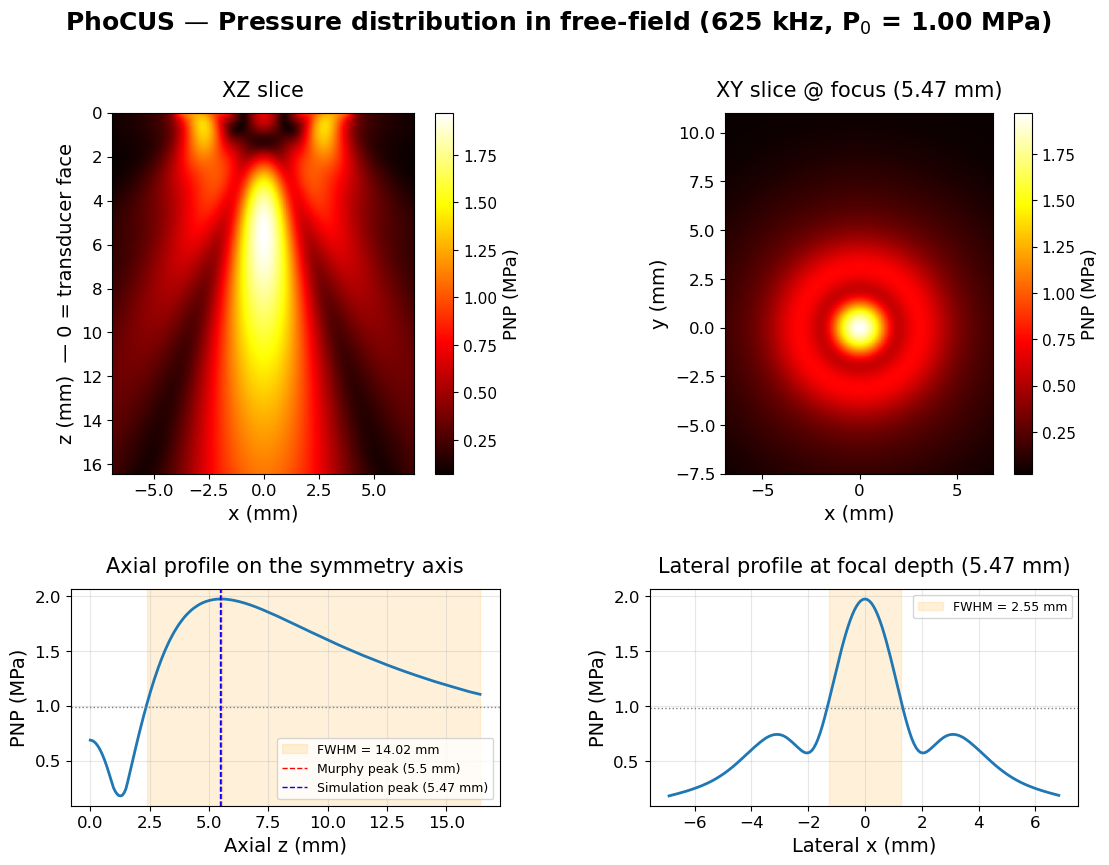

In [41]:
# XZ slice through the axis — PNP (peak negative pressure), plus XY slice at the focal peak
pnp_xz = pnp_field_free[:, TARGET_Y_IDX, :]
pnp_xy = pnp_field_free[:, :, m_free_pnp['fz']]

fig = plt.figure(figsize=(13, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.6], hspace=0.4, wspace=0.35)

# --- XZ map ---------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(pnp_xz.T/1e6,
                extent=[x_mm[0], x_mm[-1], z_mm[-1], z_mm[0]],
                aspect='equal', cmap='hot', origin='upper')
ax0.set_xlabel('x (mm)', fontsize=14)
ax0.set_ylabel('z (mm)  — 0 = transducer face', fontsize=14)
ax0.set_title(f'XZ slice', fontsize=15, pad=12)
ax0.tick_params(axis='both', labelsize=12)
cbar0 = plt.colorbar(im0, ax=ax0, label='PNP  (MPa)')
cbar0.set_label('PNP (MPa)', fontsize=13)
cbar0.ax.tick_params(labelsize=11)

# --- XY map at the focal peak ----------------------------------------
ax3 = fig.add_subplot(gs[0, 1])
im3 = ax3.imshow(pnp_xy.T/1e6,
                extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
                aspect='equal', cmap='hot', origin='lower')
ax3.set_xlabel('x (mm)', fontsize=14)
ax3.set_ylabel('y (mm)', fontsize=14)
ax3.set_title(f"XY slice @ focus ({m_free_pnp['focal_depth_mm']:.2f} mm)", fontsize=15, pad=12)
ax3.tick_params(axis='both', labelsize=12)
cbar3 = plt.colorbar(im3, ax=ax3, label='PNP (MPa)')
cbar3.set_label('PNP (MPa)', fontsize=13)
cbar3.ax.tick_params(labelsize=11)

# --- axial profile ------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(z_mm, m_free_pnp['axial']/1e6, lw=2)
ax1.axhline(m_free_pnp['axial'][m_free_pnp['fz']]/2e6, color='grey', ls=':', lw=1)
if not np.isnan(m_free_pnp['fwhm_ax_mm']):
    ax1.axvspan(m_free_pnp['zlo'], m_free_pnp['zhi'], color='orange', alpha=0.15,
                label=f"FWHM = {m_free_pnp['fwhm_ax_mm']:.2f} mm")
ax1.axvline(5.5, color='red', ls='--', lw=1, label='Murphy peak (5.5 mm)')
ax1.axvline(m_free_pnp['focal_depth_mm'], color='blue', ls='--', lw=1,
            label=f"Simulation peak ({m_free_pnp['focal_depth_mm']:.2f} mm)")
ax1.set_xlabel('Axial z (mm)', fontsize=14); ax1.set_ylabel('PNP (MPa)', fontsize=14)
ax1.set_title('Axial profile on the symmetry axis', fontsize=15, pad=12)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(alpha=0.3); ax1.legend(fontsize=9)

# --- lateral profile ----------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(x_mm, m_free_pnp['lat']/1e6, lw=2)
ax2.axhline(m_free_pnp['lat'].max()/2e6, color='grey', ls=':', lw=1)
if not np.isnan(m_free_pnp['fwhm_lat_mm']):
    ax2.axvspan(m_free_pnp['xlo'], m_free_pnp['xhi'], color='orange', alpha=0.15,
                label=f"FWHM = {m_free_pnp['fwhm_lat_mm']:.2f} mm")
ax2.set_xlabel('Lateral x (mm)', fontsize=14); ax2.set_ylabel('PNP (MPa)', fontsize=14)
ax2.set_title(f"Lateral profile at focal depth ({m_free_pnp['focal_depth_mm']:.2f} mm)", fontsize=15, pad=12)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(alpha=0.3); ax2.legend(fontsize=9)

plt.suptitle(f'PhoCUS — Pressure distribution in free-field ({RUN_TAG_PRETTY})',
             y=0.995, fontsize=18, weight='bold')
plt.savefig(f'{OUTPUT_DIR}/freefield_PNP_{RUN_TAG}.png', dpi=160, bbox_inches='tight')
plt.show()


### 9.2 Transcranial pressure-field figure

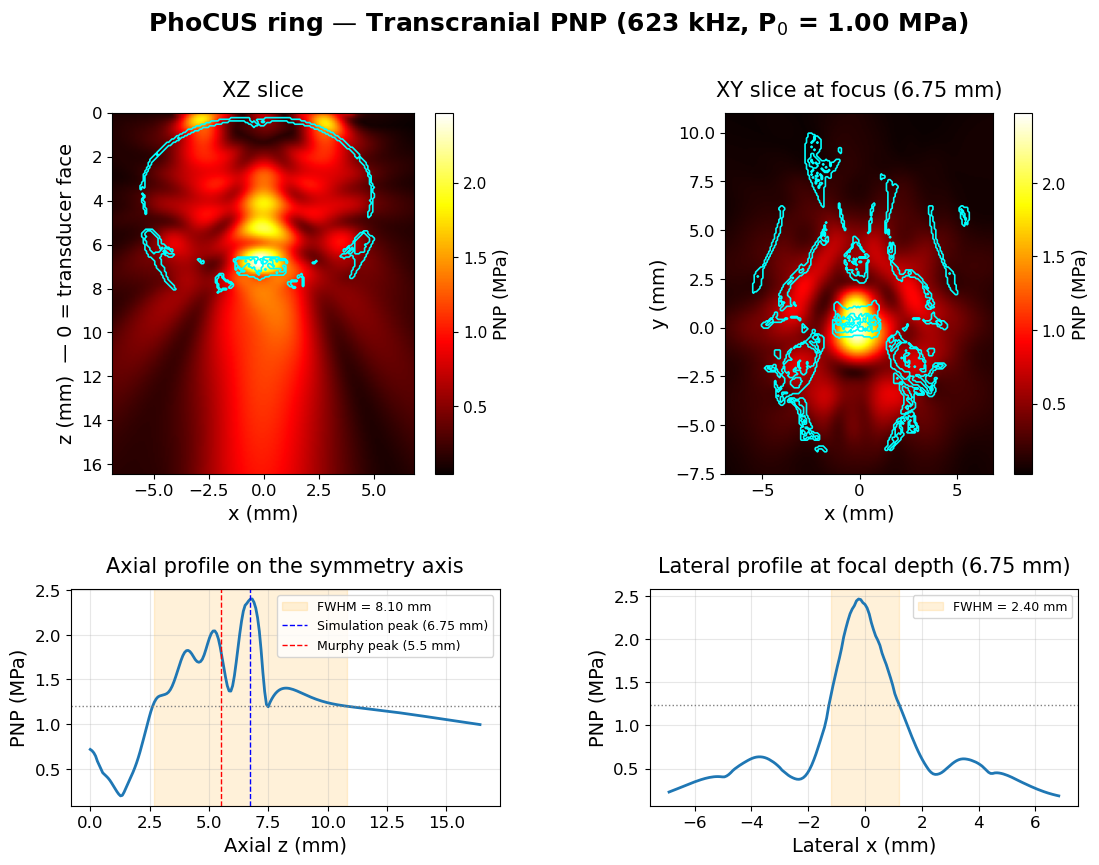

In [77]:
# XZ slice through the axis — PNP (peak negative pressure), plus XY slice at the focal peak
pnp_xz = pnp_field_skull[:, TARGET_Y_IDX, :]
pnp_xy = pnp_field_skull[:, :, m_skull_pnp['fz']]

# Matching skull-mask slices, for a cyan skull outline on both panels (same convention as
# show_sim_slice's overlay_mask elsewhere in this notebook).
skull_xz_slice = skull_mask_domain[:, TARGET_Y_IDX, :].astype(float)
skull_xy_slice = skull_mask_domain[:, :, m_skull_pnp['fz']].astype(float)

fig = plt.figure(figsize=(13, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.6], hspace=0.4, wspace=0.35)

# --- XZ map ---------------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0])
xz_extent = [x_mm[0], x_mm[-1], z_mm[-1], z_mm[0]]
im0 = ax0.imshow(pnp_xz.T/1e6,
                extent=xz_extent,
                aspect='equal', cmap='hot', origin='upper')
if skull_xz_slice.max() > 0:
    ax0.contour(skull_xz_slice.T, levels=[0.5], extent=xz_extent, origin='upper',
                colors='cyan', linewidths=1.2)
ax0.set_xlabel('x (mm)', fontsize=14)
ax0.set_ylabel('z (mm)  — 0 = transducer face', fontsize=14)
ax0.set_title(f'XZ slice', fontsize=15, pad=12)
ax0.tick_params(axis='both', labelsize=12)
cbar0 = plt.colorbar(im0, ax=ax0, label='PNP  (MPa)')
cbar0.set_label('PNP (MPa)', fontsize=13)
cbar0.ax.tick_params(labelsize=11)

# --- XY map at the focal peak ----------------------------------------
ax3 = fig.add_subplot(gs[0, 1])
xy_extent = [x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]]
im3 = ax3.imshow(pnp_xy.T/1e6,
                extent=xy_extent,
                aspect='equal', cmap='hot', origin='lower')
if skull_xy_slice.max() > 0:
    ax3.contour(skull_xy_slice.T, levels=[0.5], extent=xy_extent, origin='lower',
                colors='cyan', linewidths=1.2)
ax3.set_xlabel('x (mm)', fontsize=14)
ax3.set_ylabel('y (mm)', fontsize=14)
ax3.set_title(f"XY slice at focus ({m_skull_pnp['focal_depth_mm']:.2f} mm)", fontsize=15, pad=12)
ax3.tick_params(axis='both', labelsize=12)
cbar3 = plt.colorbar(im3, ax=ax3, label='PNP (MPa)')
cbar3.set_label('PNP (MPa)', fontsize=13)
cbar3.ax.tick_params(labelsize=11)

# --- axial profile ------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(z_mm, m_skull_pnp['axial']/1e6, lw=2)
ax1.axhline(m_skull_pnp['axial'][m_skull_pnp['fz']]/2e6, color='grey', ls=':', lw=1)
if not np.isnan(m_skull_pnp['fwhm_ax_mm']):
    ax1.axvspan(m_skull_pnp['zlo'], m_skull_pnp['zhi'], color='orange', alpha=0.15,
                label=f"FWHM = {m_skull_pnp['fwhm_ax_mm']:.2f} mm")
ax1.axvline(m_skull_pnp['focal_depth_mm'], color='blue', ls='--', lw=1,
            label=f"Simulation peak ({m_skull_pnp['focal_depth_mm']:.2f} mm)")
ax1.axvline(5.5, color='red', ls='--', lw=1, label='Murphy peak (5.5 mm)')
ax1.set_xlabel('Axial z (mm)', fontsize=14); ax1.set_ylabel('PNP (MPa)', fontsize=14)
ax1.set_title('Axial profile on the symmetry axis', fontsize=15, pad=12)
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(alpha=0.3); ax1.legend(fontsize=9)

# --- lateral profile ----------------------------------------------
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(x_mm, m_skull_pnp['lat']/1e6, lw=2)
ax2.axhline(m_skull_pnp['lat'].max()/2e6, color='grey', ls=':', lw=1)
if not np.isnan(m_skull_pnp['fwhm_lat_mm']):
    ax2.axvspan(m_skull_pnp['xlo'], m_skull_pnp['xhi'], color='orange', alpha=0.15,
                label=f"FWHM = {m_skull_pnp['fwhm_lat_mm']:.2f} mm")
ax2.set_xlabel('Lateral x (mm)', fontsize=14); ax2.set_ylabel('PNP (MPa)', fontsize=14)
ax2.set_title(f"Lateral profile at focal depth ({m_skull_pnp['focal_depth_mm']:.2f} mm)", fontsize=15, pad=12)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(alpha=0.3); ax2.legend(fontsize=9)

plt.suptitle(f'PhoCUS ring — Transcranial PNP ({RUN_TAG_PRETTY})',
             y=0.995, fontsize=18, weight='bold')
plt.savefig(f'{OUTPUT_DIR}/transcranial_PNP_{RUN_TAG}.png', dpi=160, bbox_inches='tight')
plt.show()


## 10. Slice-viewer utility

`show_sim_slice()` plots any axis/index of the simulated field or medium maps;
`ct_y_to_sim_index()` maps a native-CT slice index to the matching simulation-grid index.

In [ ]:
def show_sim_slice(volume, axis, index=None, coord_mm=None, ax=None, cmap='hot',
                    title=None, extent_mm=None, overlay_mask=None, overlay_color='cyan',
                    **imkw):
    '''axis: 'x','y','z' (0,1,2). Give either `index` (voxel) or `coord_mm` (physical, mm
    from the array centre for x/y, from the transducer face for z).
    overlay_mask: optional array on the same (Nx,Ny,Nz) grid (e.g. skull_mask_domain) --
    its 0.5-contour is drawn on top so you can see where the skull sits relative to the field.'''
    axis_map = {'x': 0, 'y': 1, 'z': 2}
    ax_idx = axis_map[axis]
    axes_mm = {'x': x_mm, 'y': y_mm, 'z': z_mm}
    if coord_mm is not None:
        index = int(np.argmin(np.abs(axes_mm[axis] - coord_mm)))
    if index is None:
        index = volume.shape[ax_idx] // 2
    sl = [slice(None)] * 3
    sl[ax_idx] = index
    img = volume[tuple(sl)]

    other_axes = [a for a in ('x', 'y', 'z') if a != axis]
    if extent_mm is None:
        extent_mm = [axes_mm[other_axes[0]][0], axes_mm[other_axes[0]][-1],
                     axes_mm[other_axes[1]][-1], axes_mm[other_axes[1]][0]]
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(img.T, extent=extent_mm, aspect='equal', origin='upper', cmap=cmap, **imkw)

    if overlay_mask is not None:
        mask_slice = overlay_mask[tuple(sl)].astype(float)
        if mask_slice.max() > 0:   # skip the contour call if this slice misses the skull entirely
            ax.contour(mask_slice.T, levels=[0.5], extent=extent_mm, origin='upper',
                       colors=overlay_color, linewidths=1.2)

    ax.set_xlabel(f'{other_axes[0]} (mm)'); ax.set_ylabel(f'{other_axes[1]} (mm)')
    ax.set_title(title or f'{axis} = {axes_mm[axis][index]:.2f} mm  (index {index})')
    plt.colorbar(im, ax=ax, shrink=0.8)
    return ax, index


def ct_y_to_sim_index(ct_y_index, axis='y'):
    '''Map a native-CT voxel index on the given axis to the matching index on the
    simulation grid, using the same zoom_factor / placement offset applied in §4.'''
    axis_map = {'x': (0, 'x0'), 'y': (1, 'y0'), 'z': (2, 'z0')}
    native_ax, offset_key = axis_map[axis]
    sim_local_index = int(round(ct_y_index * zoom_factor[native_ax]))
    return sim_local_index + skull_placement[offset_key]




## 11. Free field vs. transcranial comparison (Section 3.1.1 from Results)

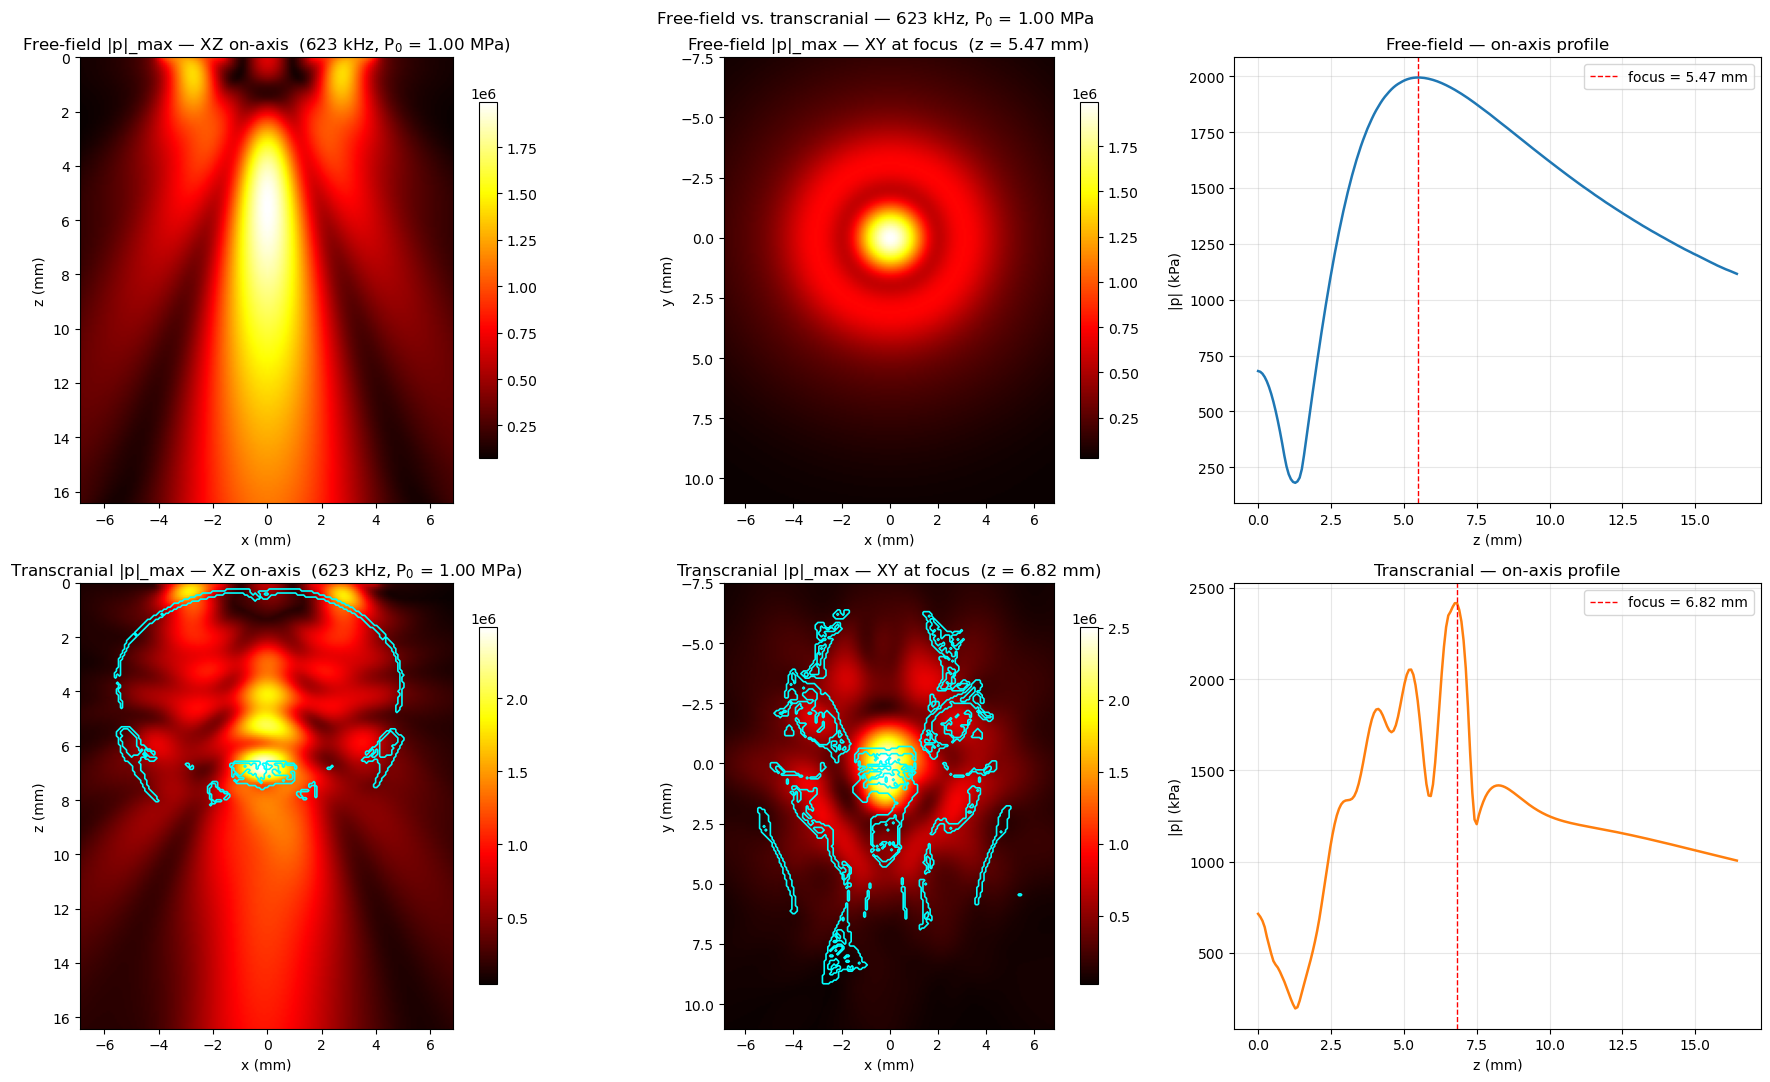

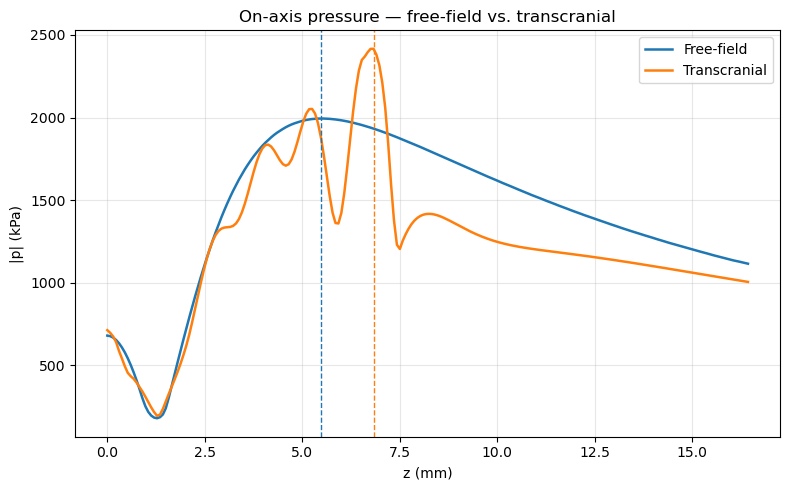

Focal shift    : +1.35 mm
Insertion loss : -1.67 dB


In [44]:
# =========================================================================
# FREE-FIELD vs TRANSCRANIAL — side-by-side comparison
# =========================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 0: free-field
show_sim_slice(p_max_free, 'y', index=TARGET_Y_IDX, ax=axes[0, 0], cmap='hot',
               title=f'Free-field |p|_max — XZ on-axis  ({RUN_TAG_PRETTY})')
show_sim_slice(p_max_free, 'z', index=m_free['fz'], ax=axes[0, 1], cmap='hot',
               title=f"Free-field |p|_max — XY at focus  (z = {z_mm[m_free['fz']]:.2f} mm)")
axial_free = p_max_free[xc, TARGET_Y_IDX, :]
axes[0, 2].plot(z_mm, axial_free / 1e3, lw=1.8, color='tab:blue')
axes[0, 2].axvline(z_mm[m_free['fz']], color='r', ls='--', lw=1,
                    label=f"focus = {z_mm[m_free['fz']]:.2f} mm")
axes[0, 2].set_xlabel('z (mm)'); axes[0, 2].set_ylabel('|p| (kPa)')
axes[0, 2].set_title('Free-field — on-axis profile')
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

# Row 1: transcranial
show_sim_slice(p_max_skull, 'y', index=TARGET_Y_IDX, ax=axes[1, 0], cmap='hot',
               overlay_mask=skull_mask_domain,
               title=f'Transcranial |p|_max — XZ on-axis  ({RUN_TAG_PRETTY})')
show_sim_slice(p_max_skull, 'z', index=m_skull['fz'], ax=axes[1, 1], cmap='hot',
               overlay_mask=skull_mask_domain,
               title=f"Transcranial |p|_max — XY at focus  (z = {z_mm[m_skull['fz']]:.2f} mm)")
axial_skull = p_max_skull[xc, TARGET_Y_IDX, :]
axes[1, 2].plot(z_mm, axial_skull / 1e3, lw=1.8, color='tab:orange')
axes[1, 2].axvline(z_mm[m_skull['fz']], color='r', ls='--', lw=1,
                    label=f"focus = {z_mm[m_skull['fz']]:.2f} mm")
axes[1, 2].set_xlabel('z (mm)'); axes[1, 2].set_ylabel('|p| (kPa)')
axes[1, 2].set_title('Transcranial — on-axis profile')
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)

plt.suptitle(f'Free-field vs. transcranial — {RUN_TAG_PRETTY}'
             + (' [SYNTHETIC PLACEHOLDER SKULL]' if CT_IS_SYNTHETIC else ''))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/freefield_vs_transcranial_{RUN_TAG}.png', dpi=160)
plt.show()

# Direct overlay of both axial profiles on one axes
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_mm, axial_free / 1e3,  lw=1.8, color='tab:blue',   label='Free-field')
ax.plot(z_mm, axial_skull / 1e3, lw=1.8, color='tab:orange', label='Transcranial')
ax.axvline(z_mm[m_free['fz']],  color='tab:blue',   ls='--', lw=1)
ax.axvline(z_mm[m_skull['fz']], color='tab:orange', ls='--', lw=1)
ax.set_xlabel('z (mm)'); ax.set_ylabel('|p| (kPa)')
ax.set_title('On-axis pressure — free-field vs. transcranial')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/axial_comparison_{RUN_TAG}.png', dpi=160)
plt.show()

print(f"Focal shift    : {m_skull['focal_depth_mm'] - m_free['focal_depth_mm']:+.2f} mm")
print(f"Insertion loss : {20*np.log10(m_free['peak_kPa']/m_skull['peak_kPa']):.2f} dB")

### 11.1 Free-field only

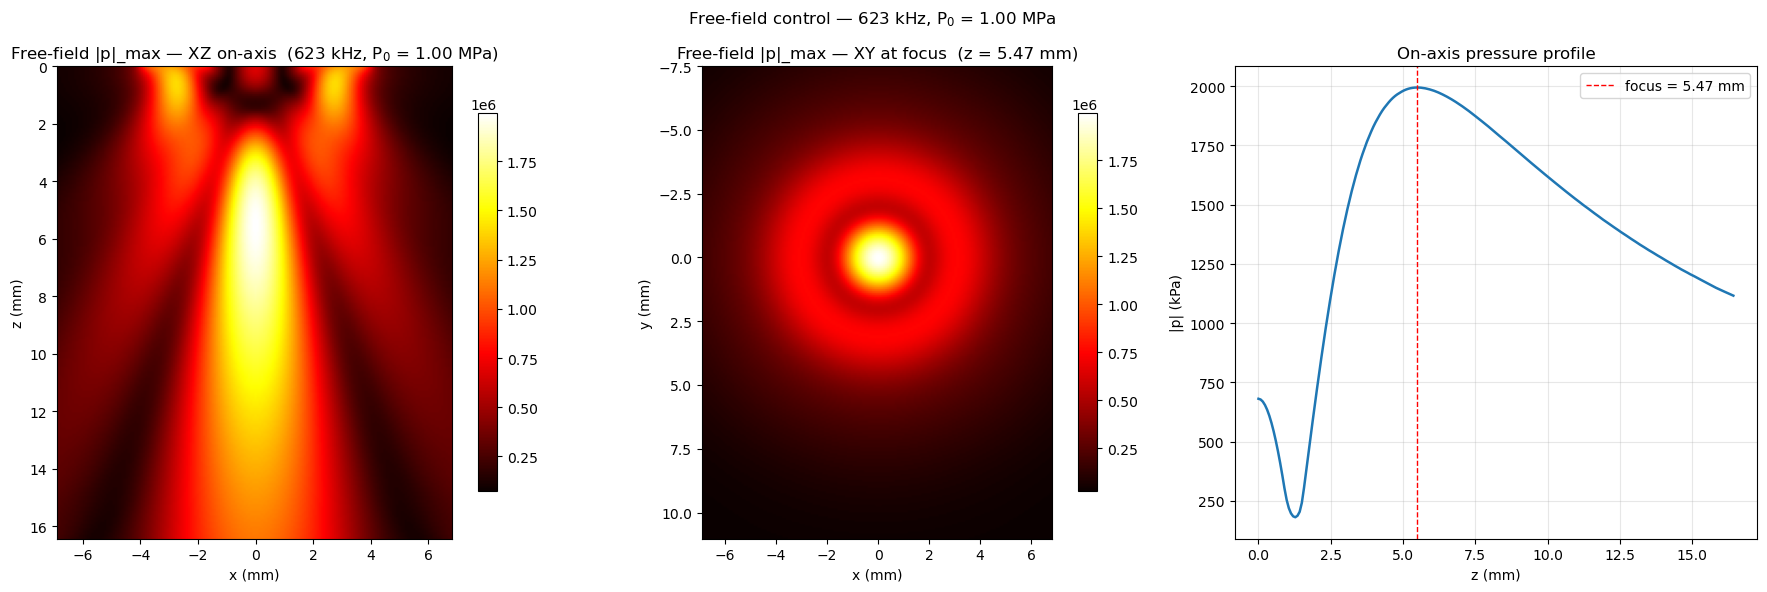

Free-field focal depth : 5.47 mm
Free-field peak        : 1994.1 kPa
Free-field FWHM axial  : 14.02 mm
Free-field FWHM lateral: 2.55 mm


In [45]:
# =========================================================================
# FREE-FIELD ONLY — standalone visualization (no skull, no comparison)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

show_sim_slice(p_max_free, 'y', index=TARGET_Y_IDX, ax=axes[0], cmap='hot',
               title=f'Free-field |p|_max — XZ on-axis  ({RUN_TAG_PRETTY})')

show_sim_slice(p_max_free, 'z', index=m_free['fz'], ax=axes[1], cmap='hot',
               title=f"Free-field |p|_max — XY at focus  (z = {z_mm[m_free['fz']]:.2f} mm)")

axial_free = p_max_free[xc, TARGET_Y_IDX, :]
axes[2].plot(z_mm, axial_free / 1e3, lw=1.8)
axes[2].axvline(z_mm[m_free['fz']], color='r', ls='--', lw=1,
                label=f"focus = {z_mm[m_free['fz']]:.2f} mm")
axes[2].set_xlabel('z (mm)'); axes[2].set_ylabel('|p| (kPa)')
axes[2].set_title('On-axis pressure profile')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Free-field control — {RUN_TAG_PRETTY}')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/freefield_only_{RUN_TAG}.png', dpi=160)
plt.show()

print(f"Free-field focal depth : {m_free['focal_depth_mm']:.2f} mm")
print(f"Free-field peak        : {m_free['peak_kPa']:.1f} kPa")
print(f"Free-field FWHM axial  : {m_free['fwhm_ax_mm']:.2f} mm")
print(f"Free-field FWHM lateral: {m_free['fwhm_lat_mm']:.2f} mm")

### 11.2 Transcranial only

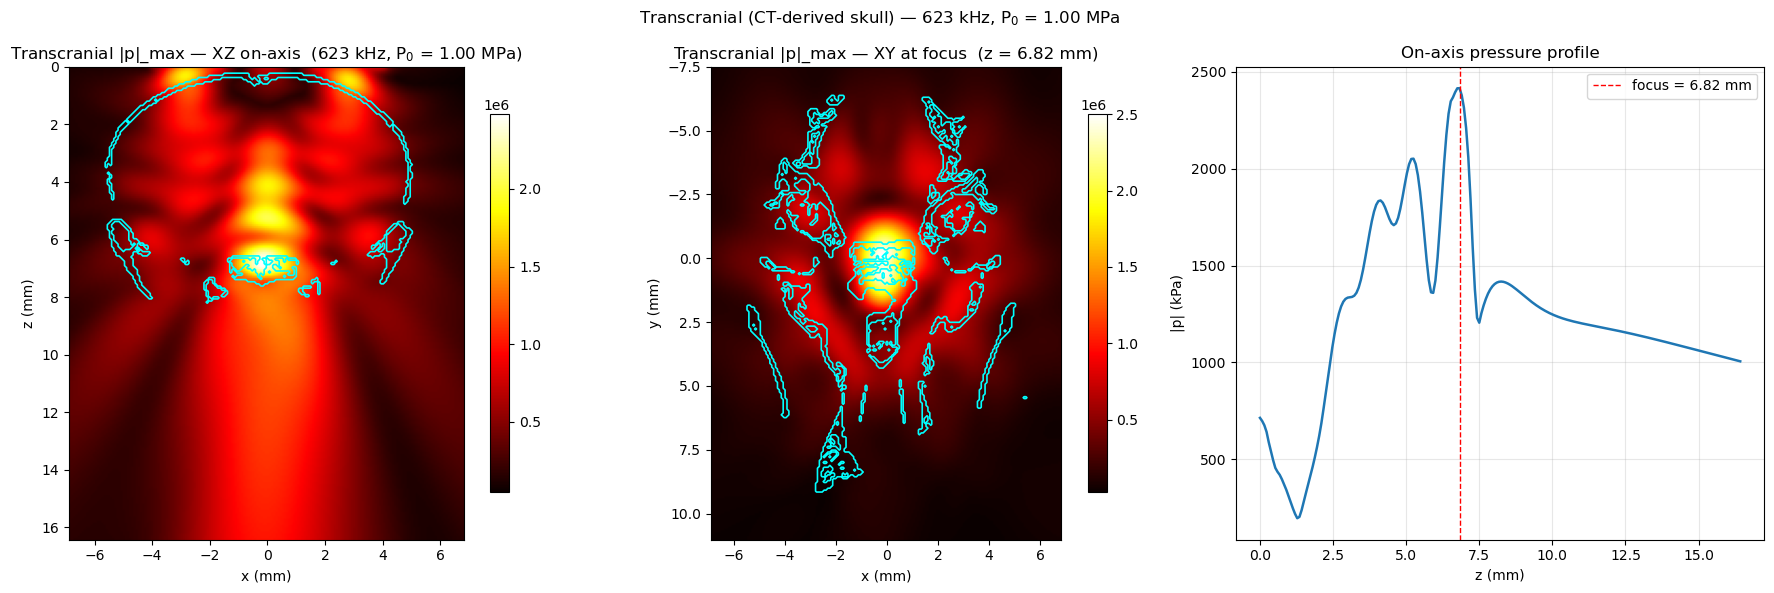

Transcranial focal depth : 6.82 mm
Transcranial peak        : 2416.0 kPa
Transcranial FWHM axial  : 8.10 mm
Transcranial FWHM lateral: 2.40 mm


In [46]:
# =========================================================================
# TRANSCRANIAL — standalone visualization (through CT-derived skull)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

show_sim_slice(p_max_skull, 'y', index=TARGET_Y_IDX, ax=axes[0], cmap='hot',
               overlay_mask=skull_mask_domain,
               title=f'Transcranial |p|_max — XZ on-axis  ({RUN_TAG_PRETTY})')

show_sim_slice(p_max_skull, 'z', index=m_skull['fz'], ax=axes[1], cmap='hot',
               overlay_mask=skull_mask_domain,
               title=f"Transcranial |p|_max — XY at focus  (z = {z_mm[m_skull['fz']]:.2f} mm)")

axial_skull = p_max_skull[xc, TARGET_Y_IDX, :]
axes[2].plot(z_mm, axial_skull / 1e3, lw=1.8)
axes[2].axvline(z_mm[m_skull['fz']], color='r', ls='--', lw=1,
                label=f"focus = {z_mm[m_skull['fz']]:.2f} mm")
axes[2].set_xlabel('z (mm)'); axes[2].set_ylabel('|p| (kPa)')
axes[2].set_title('On-axis pressure profile')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Transcranial (CT-derived skull) — {RUN_TAG_PRETTY}'
             + (' [SYNTHETIC PLACEHOLDER SKULL]' if CT_IS_SYNTHETIC else ''))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/transcranial_only_{RUN_TAG}.png', dpi=160)
plt.show()

print(f"Transcranial focal depth : {m_skull['focal_depth_mm']:.2f} mm")
print(f"Transcranial peak        : {m_skull['peak_kPa']:.1f} kPa")
print(f"Transcranial FWHM axial  : {m_skull['fwhm_ax_mm']:.2f} mm")
print(f"Transcranial FWHM lateral: {m_skull['fwhm_lat_mm']:.2f} mm")

### 11.3 On-axis XZ view 

In [ ]:
# On-axis XZ view (Murphy Fig. 1B), with skull outline:
fig, ax = plt.subplots(figsize=(6, 8))
show_sim_slice(p_max_skull, 'y', index=yc, ax=ax, overlay_mask=skull_mask_domain,
               title='Transcranial |p|_max — on-axis XZ slice')
plt.tight_layout(); plt.show()